# KS vs AD Optimal Region Comparison (from Cached Results)

Compares the overlap in r-eta parameter space between KS and AD test results, using pre-computed cached pickle dictionaries from the KS and AD testing pipelines. No recomputation needed.

In [1]:
DATA_NAME = 'pastis-full' 
TRANSFORM = 'wavelet-horizVert'
CHANNEL = 'gray'

In [2]:
import git
from pathlib import Path
import os
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)

path_list = DATA_NAME.split("-") + TRANSFORM.split("-")
if CHANNEL:
    path_list.append(CHANNEL)
FULL_DATA_NAME = '-'.join(path_list)

GROUP = 'layer' if TRANSFORM.split("-")[0] == 'wavelet' else ('band' if TRANSFORM.split("-")[0] == 'fourier' else 'error')

# Paths to pre-computed results
KS_RES_DIR = os.path.join(ROOT_DIR, "results", "case-studies", *path_list)
#AD_RES_DIR = os.path.join(ROOT_DIR, "anderson-darling", "ad-pipeline-tests", f"ad_{'_'.join(path_list)}")
AD_RES_DIR = "/Users/michaelmurphy/Documents/GitHub/hierarchical-bayesian-model-validation/anderson-darling/ad-pipeline-tests/ad_wavelet_pastis_gray"

print(f"KS results: {KS_RES_DIR}")
print(f"AD results: {AD_RES_DIR}")
print(f"Group key: {GROUP}")

KS results: /Users/michaelmurphy/Documents/GitHub/hierarchical-bayesian-model-validation/results/case-studies/pastis/full/wavelet/horizVert/gray
AD results: /Users/michaelmurphy/Documents/GitHub/hierarchical-bayesian-model-validation/anderson-darling/ad-pipeline-tests/ad_wavelet_pastis_gray
Group key: layer


In [3]:
os.chdir(os.path.join(ROOT_DIR, 'anderson-darling'))
from testing_ad import ad_asymptotic_cdf
os.chdir(os.path.join(ROOT_DIR, 'anderson-darling', 'ks-ad-comparisons'))

## Load Cached Results

In [4]:
# Load cached pickle dictionaries
rEtaKsstats_dict = pd.read_pickle(os.path.join(KS_RES_DIR, "cache", "rEtaKsstats_dict.pickle"))
rEtaAdstats_dict = pd.read_pickle(os.path.join(AD_RES_DIR, "cache", "rEtaAdstats_dict.pickle"))

# Load optimized master DataFrames
ks_master_df = pd.read_csv(os.path.join(KS_RES_DIR, "CSVs", "master_df_optimized.csv"), index_col=GROUP)
ad_master_df = pd.read_csv(os.path.join(AD_RES_DIR, "CSVs", "master_df_optimized_ad.csv"), index_col=GROUP)

# Load sample sizes for KS cutoff computation
group_total_samples = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}-size.pickle'))

# Find groups present in both KS and AD results
ks_groups = set(rEtaKsstats_dict.keys())
ad_groups = set(rEtaAdstats_dict.keys())
common_groups = sorted(ks_groups & ad_groups)

print(f"KS groups: {sorted(ks_groups)}")
print(f"AD groups: {sorted(ad_groups)}")
print(f"Common groups: {common_groups}")

KS groups: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
AD groups: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Common groups: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## Extract Best Stats Per (r, eta) from Cached Dictionaries

Each pickle stores per-group dictionaries with columns: `r`, `eta`, `ksstat_exclude_0`, `ksstat_exclude_25`, ... (or `adstat_exclude_*`). We extract the minimum stat across all exclude cutoffs at each (r, eta) point — this matches what the grid search does to find the best scale/cutoff.

In [5]:
def extract_best_stats(stats_dict, prefix):
    """
    From a per-group stats dictionary, build a DataFrame with columns r, eta, and 
    the best (minimum) test statistic across all exclude cutoffs.
    
    prefix: 'ksstat' or 'adstat'
    """
    df = pd.DataFrame(stats_dict)
    
    # Identify coarse grid columns (exclude optimization columns)
    stat_cols = [c for c in df.columns if c.startswith(f'{prefix}_exclude_') and 'plus' not in c and 'minus' not in c]
    
    # Use the coarse grid r, eta (not r_optimize, eta_optimize)
    r_col = 'r'
    eta_col = 'eta'
    
    result = pd.DataFrame({
        'r': df[r_col].values,
        'eta': df[eta_col].values,
        f'best_{prefix}': df[stat_cols].min(axis=1).values
    })
    
    return result

# Also extract fine grid stats if optimization was run
def extract_fine_stats(stats_dict, prefix):
    """Extract optimization (fine grid) stats if available."""
    df = pd.DataFrame(stats_dict)
    if 'r_optimize' not in df.columns:
        return None
    
    stat_cols = [c for c in df.columns if c.startswith(f'{prefix}_exclude_') and ('plus' in c or 'minus' in c)]
    if not stat_cols:
        return None
    
    result = pd.DataFrame({
        'r': df['r_optimize'].values,
        'eta': df['eta_optimize'].values,
        f'best_{prefix}': df[stat_cols].min(axis=1).values
    })
    return result

## Per-Group Overlap Analysis on Coarse Grid

For each common group, merge the KS and AD coarse-grid stats on (r, eta), apply test cutoffs, and classify each grid point.

In [6]:
alpha = 0.05

# AD cutoff is n-independent (asymptotic)
ad_cutoff = scipy.optimize.fsolve(lambda x: 1 - ad_asymptotic_cdf(x, N=10) - alpha, 1)[0]
print(f"AD cutoff at alpha={alpha}: {ad_cutoff:.4f}")

group_results = {}

for group in common_groups:
    n = group_total_samples[group]
    
    # KS cutoff is n-dependent
    ks_cutoff = stats.kstwo.isf(alpha, n)
    
    # Extract coarse grid stats
    ks_df = extract_best_stats(rEtaKsstats_dict[group], 'ksstat')
    ad_df = extract_best_stats(rEtaAdstats_dict[group], 'adstat')
    
    # Merge on (r, eta) — round to avoid floating point mismatches
    ks_df['r_round'] = np.round(ks_df['r'], 4)
    ks_df['eta_round'] = np.round(ks_df['eta'], 4)
    ad_df['r_round'] = np.round(ad_df['r'], 4)
    ad_df['eta_round'] = np.round(ad_df['eta'], 4)
    
    merged = ks_df.merge(ad_df, on=['r_round', 'eta_round'], suffixes=('_ks', '_ad'))
    merged['r'] = merged['r_ks']
    merged['eta'] = merged['eta_ks']
    
    # Apply cutoffs
    merged['ks_pass'] = merged['best_ksstat'] < ks_cutoff
    merged['ad_pass'] = merged['best_adstat'] < ad_cutoff
    merged['pass_summary'] = np.select(
        [merged['ks_pass'] & merged['ad_pass'], merged['ks_pass'], merged['ad_pass']],
        ['Both', 'Only KS', 'Only AD'], 'Neither'
    )
    
    group_results[group] = merged
    
    counts = merged['pass_summary'].value_counts()
    print(f"\n{GROUP.capitalize()} {group} (n={n:,}, KS cutoff={ks_cutoff:.6f}):")
    for cat in ['Both', 'Only KS', 'Only AD', 'Neither']:
        print(f"  {cat}: {counts.get(cat, 0)}")

AD cutoff at alpha=0.05: 2.4924

Layer 2 (n=3,180, KS cutoff=0.024030):
  Both: 93
  Only KS: 729
  Only AD: 10
  Neither: 11928

Layer 3 (n=12,720, KS cutoff=0.012029):
  Both: 210
  Only KS: 453
  Only AD: 1
  Neither: 12096

Layer 4 (n=50,880, KS cutoff=0.006018):
  Both: 0
  Only KS: 7
  Only AD: 0
  Neither: 12753

Layer 5 (n=203,520, KS cutoff=0.003010):
  Both: 0
  Only KS: 1
  Only AD: 0
  Neither: 12759

Layer 6 (n=814,080, KS cutoff=0.001505):
  Both: 0
  Only KS: 0
  Only AD: 0
  Neither: 12760

Layer 7 (n=3,256,320, KS cutoff=0.000753):
  Both: 0
  Only KS: 0
  Only AD: 0
  Neither: 12760

Layer 8 (n=13,025,280, KS cutoff=0.000376):
  Both: 0
  Only KS: 0
  Only AD: 0
  Neither: 12760


## Overlap Summary Table

In [7]:
summary_rows = []
for group in common_groups:
    merged = group_results[group]
    counts = merged['pass_summary'].value_counts()
    n_both = counts.get('Both', 0)
    n_ks_only = counts.get('Only KS', 0)
    n_ad_only = counts.get('Only AD', 0)
    n_neither = counts.get('Neither', 0)
    n_ks_pass = n_both + n_ks_only
    n_ad_pass = n_both + n_ad_only
    n_union = n_both + n_ks_only + n_ad_only
    jaccard = n_both / n_union if n_union > 0 else np.nan
    
    summary_rows.append({
        GROUP: group,
        'total_grid_pts': len(merged),
        'Both': n_both,
        'Only KS': n_ks_only,
        'Only AD': n_ad_only,
        'Neither': n_neither,
        'KS pass': n_ks_pass,
        'AD pass': n_ad_pass,
        'Union': n_union,
        'Jaccard (Both/Union)': round(jaccard, 3)
    })

summary_df = pd.DataFrame(summary_rows).set_index(GROUP)
summary_df

,total_grid_pts,Both,Only KS,Only AD,Neither,KS pass,AD pass,Union,Jaccard (Both/Union)
layer,,,,,,,,,
2,12760,93,729,10,11928,822,103,832,0.112
3,12760,210,453,1,12096,663,211,664,0.316
4,12760,0,7,0,12753,7,0,7,0.000
5,12760,0,1,0,12759,1,0,1,0.000
6,12760,0,0,0,12760,0,0,0,NaN
7,12760,0,0,0,12760,0,0,0,NaN
8,12760,0,0,0,12760,0,0,0,NaN


## Compare Optimized Best Parameters (KS vs AD)

In [8]:
common_master_groups = sorted(set(ks_master_df.index) & set(ad_master_df.index))

param_comparison = pd.DataFrame(index=common_master_groups)
param_comparison.index.name = GROUP

param_comparison['ks_best_r'] = ks_master_df.loc[common_master_groups, 'best_r']
param_comparison['ks_best_eta'] = ks_master_df.loc[common_master_groups, 'best_eta']
param_comparison['ks_best_stat'] = ks_master_df.loc[common_master_groups, 'kstest_stat_best']

param_comparison['ad_best_r'] = ad_master_df.loc[common_master_groups, 'best_r']
param_comparison['ad_best_eta'] = ad_master_df.loc[common_master_groups, 'best_eta']
param_comparison['ad_best_stat'] = ad_master_df.loc[common_master_groups, 'adtest_stat_best']

param_comparison['delta_r'] = param_comparison['ad_best_r'] - param_comparison['ks_best_r']
param_comparison['delta_eta'] = param_comparison['ad_best_eta'] - param_comparison['ks_best_eta']
param_comparison['euclidean_dist'] = np.sqrt(param_comparison['delta_r']**2 + param_comparison['delta_eta']**2)

param_comparison

,ks_best_r,ks_best_eta,ks_best_stat,ad_best_r,ad_best_eta,ad_best_stat,delta_r,delta_eta,euclidean_dist
layer,,,,,,,,,
2,5.00,-0.32,0.017339,0.40,1.30,2.009593,-4.60,1.62,4.876925
3,0.38,1.50,0.004103,0.46,0.90,0.295827,0.08,-0.60,0.605310
4,0.42,0.40,0.004938,0.58,-0.10,2.423433,0.16,-0.50,0.524976
5,0.50,-0.33,0.001851,0.50,-0.34,1.550063,0.00,-0.01,0.010000
6,0.35,-0.30,0.003292,0.42,-0.50,16.836590,0.07,-0.20,0.211896
7,0.25,-0.20,0.005021,0.35,-0.60,191.242976,0.10,-0.40,0.412311
8,0.20,-0.01,0.006170,0.22,-0.20,1323.724910,0.02,-0.19,0.191050


## Cross-Test Check: Does the KS-optimal point also pass AD, and vice versa?

In [9]:
cross_check_rows = []
for group in common_groups:
    merged = group_results[group]
    n = group_total_samples[group]
    ks_cutoff = stats.kstwo.isf(alpha, n)
    
    # Find the KS-optimal point and check its AD stat
    ks_best_idx = merged['best_ksstat'].idxmin()
    ks_best_row = merged.loc[ks_best_idx]
    
    # Find the AD-optimal point and check its KS stat
    ad_best_idx = merged['best_adstat'].idxmin()
    ad_best_row = merged.loc[ad_best_idx]
    
    cross_check_rows.append({
        GROUP: group,
        'ks_opt_r': ks_best_row['r'],
        'ks_opt_eta': ks_best_row['eta'],
        'ks_opt_ksstat': ks_best_row['best_ksstat'],
        'ks_opt_adstat': ks_best_row['best_adstat'],
        'ks_opt_passes_ad': ks_best_row['best_adstat'] < ad_cutoff,
        'ad_opt_r': ad_best_row['r'],
        'ad_opt_eta': ad_best_row['eta'],
        'ad_opt_adstat': ad_best_row['best_adstat'],
        'ad_opt_ksstat': ad_best_row['best_ksstat'],
        'ad_opt_passes_ks': ad_best_row['best_ksstat'] < ks_cutoff,
    })

cross_check_df = pd.DataFrame(cross_check_rows).set_index(GROUP)
cross_check_df

,ks_opt_r,ks_opt_eta,ks_opt_ksstat,ks_opt_adstat,ks_opt_passes_ad,ad_opt_r,ad_opt_eta,ad_opt_adstat,ad_opt_ksstat,ad_opt_passes_ks
layer,,,,,,,,,,
2,5.1,-0.3,0.017402,4.497028,False,0.4,1.3,2.009593,0.017908,True
3,0.4,1.3,0.004248,0.303122,True,0.4,1.3,0.303122,0.004248,True
4,0.4,0.5,0.004980,2.949832,False,0.5,0.1,2.523017,0.005859,True
5,0.5,-0.3,0.002598,3.547876,False,0.6,-0.5,3.349259,0.003210,False
6,0.3,-0.1,0.003870,40.260446,False,0.5,-0.6,36.907747,0.004681,False
7,0.3,-0.4,0.005205,302.359792,False,0.4,-0.7,240.446775,0.009196,False
8,0.2,0.0,0.006180,1892.141635,False,0.2,-0.1,1580.151644,0.008938,False


## Visualize r-eta Pass/Fail Regions Per Group

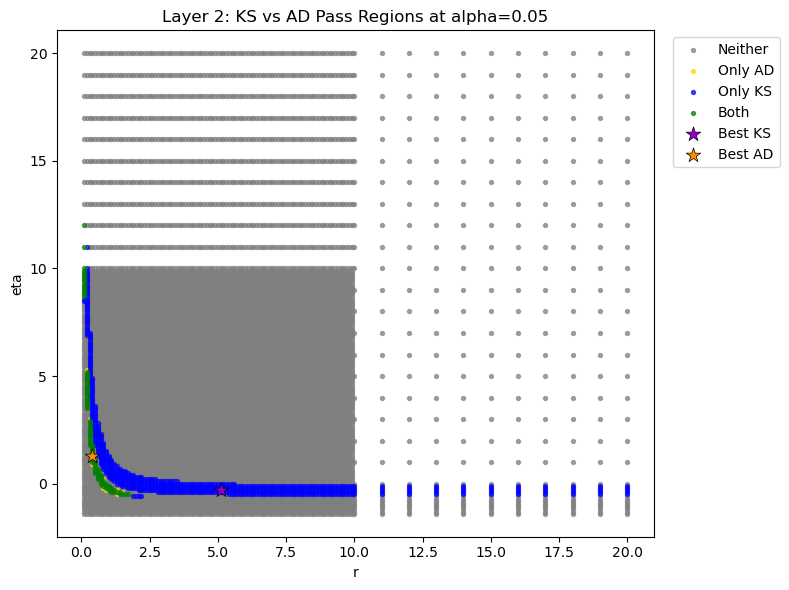

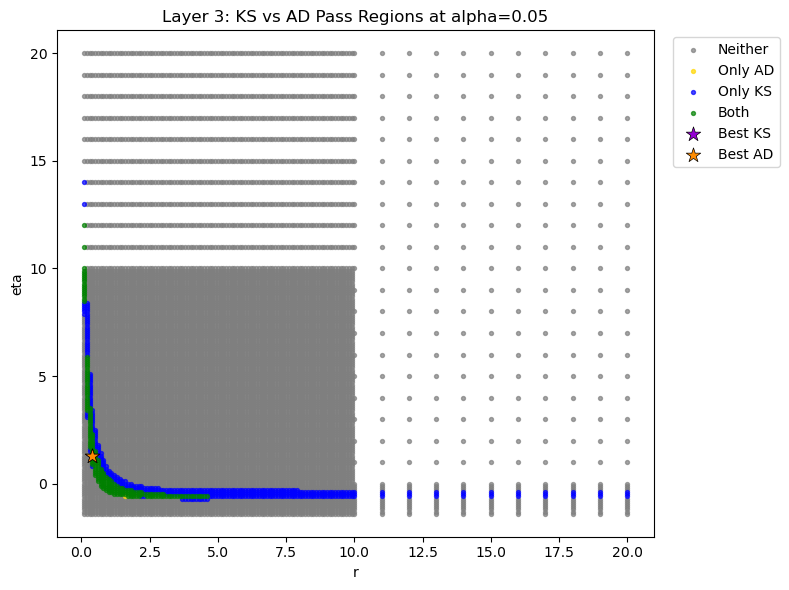

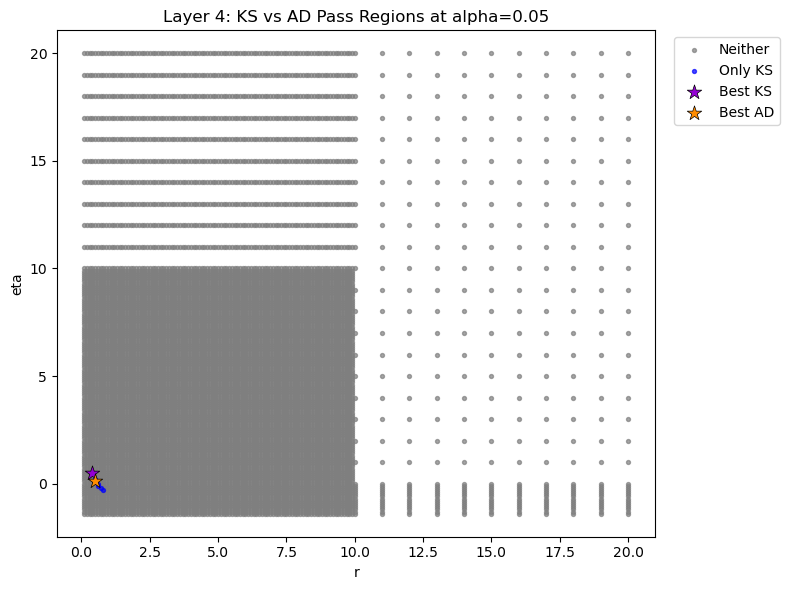

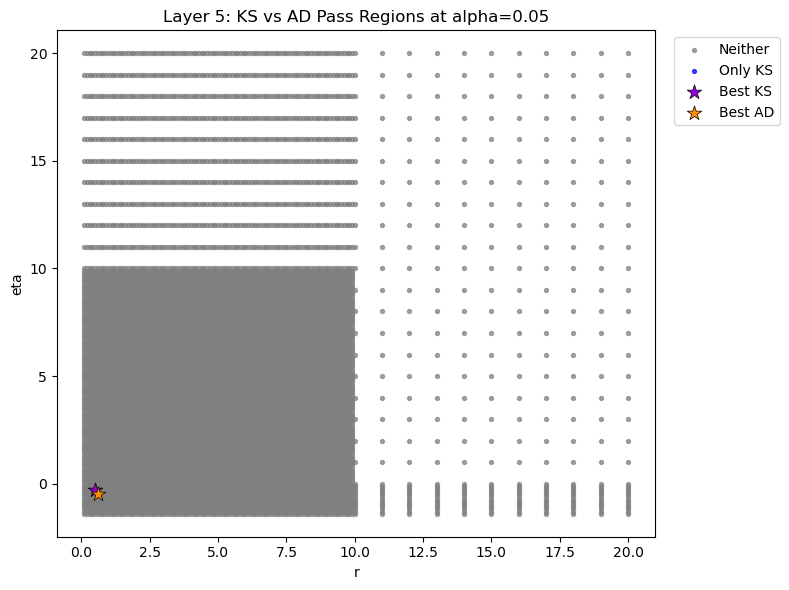

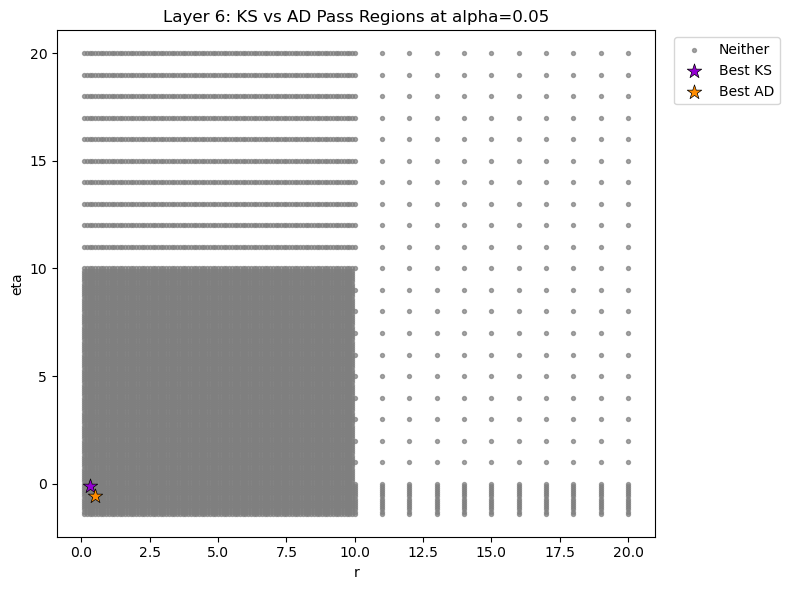

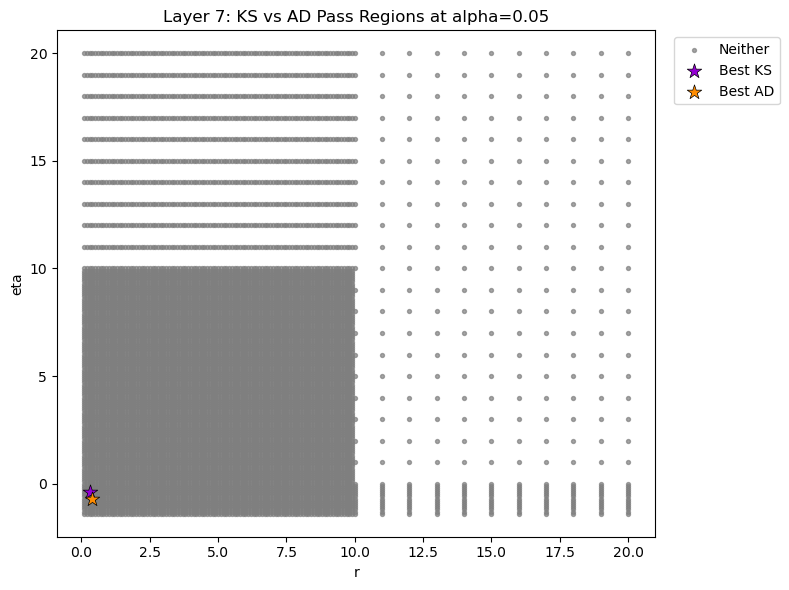

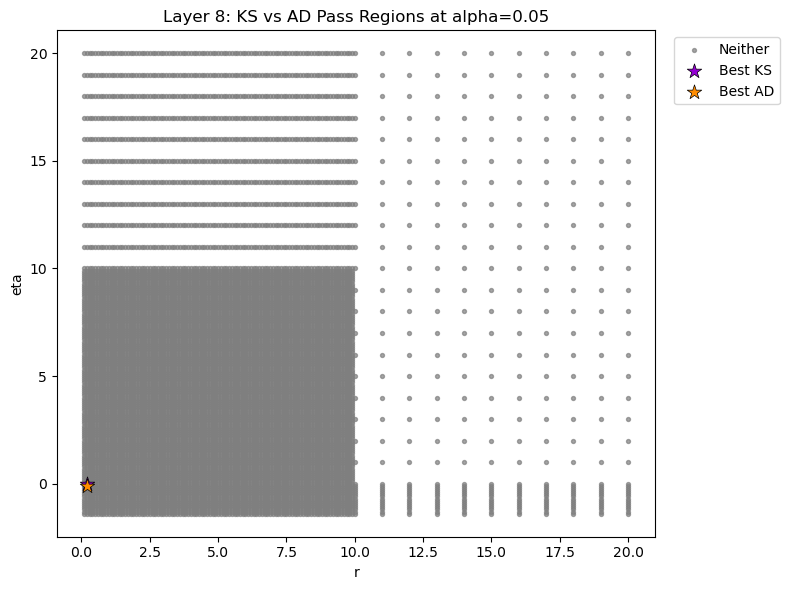

In [10]:
palette = {
    'Both': 'green',
    'Only KS': 'blue',
    'Only AD': 'gold',
    'Neither': 'tab:gray'
}

for group in common_groups:
    fig, ax = plt.subplots(figsize=(8, 6))
    merged = group_results[group]
    
    for cat in ['Neither', 'Only AD', 'Only KS', 'Both']:
        subset = merged[merged['pass_summary'] == cat]
        if len(subset) > 0:
            ax.scatter(subset['r'], subset['eta'], s=8, c=palette[cat], label=cat, alpha=0.7)
    
    ks_best = merged.loc[merged['best_ksstat'].idxmin()]
    ad_best = merged.loc[merged['best_adstat'].idxmin()]
    ax.scatter([ks_best['r']], [ks_best['eta']], marker='*', s=120, c='darkviolet', 
               edgecolors='black', linewidths=0.5, zorder=5, label='Best KS')
    ax.scatter([ad_best['r']], [ad_best['eta']], marker='*', s=120, c='darkorange', 
               edgecolors='black', linewidths=0.5, zorder=5, label='Best AD')
    
    ax.set_xlabel('r')
    ax.set_ylabel('eta')
    ax.set_title(f'{GROUP.capitalize()} {group}: KS vs AD Pass Regions at alpha={alpha}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    plt.show()

## Zoomed View: Passing Regions Only

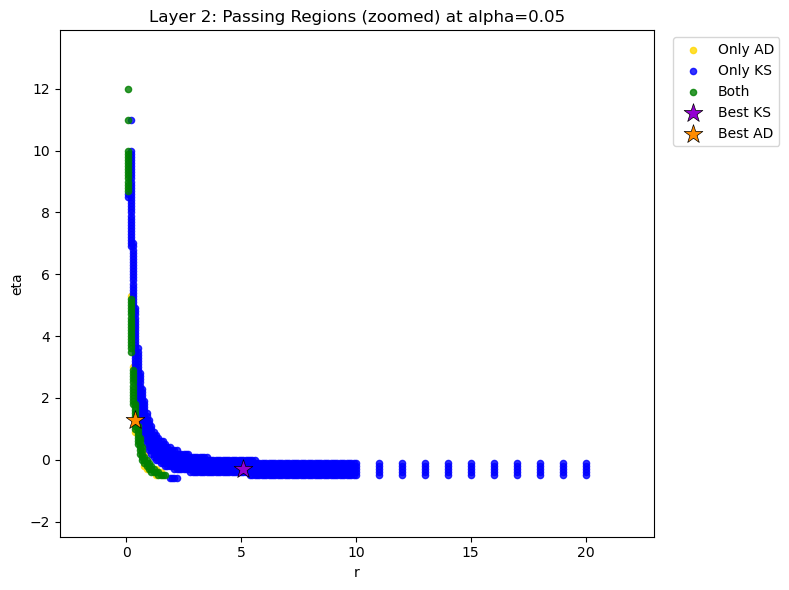

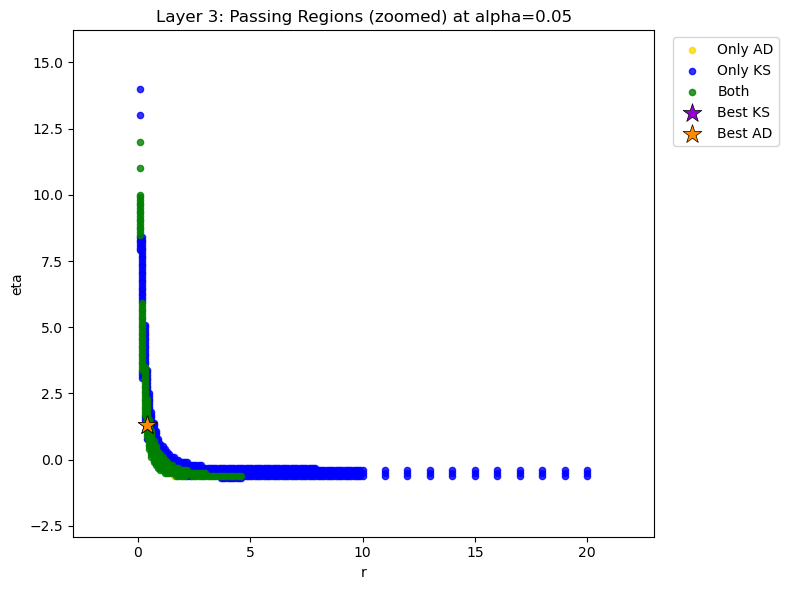

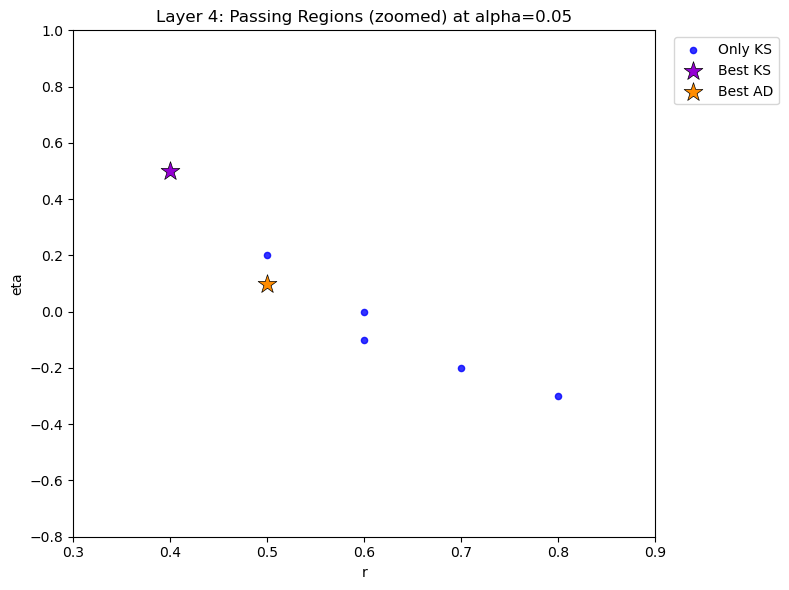

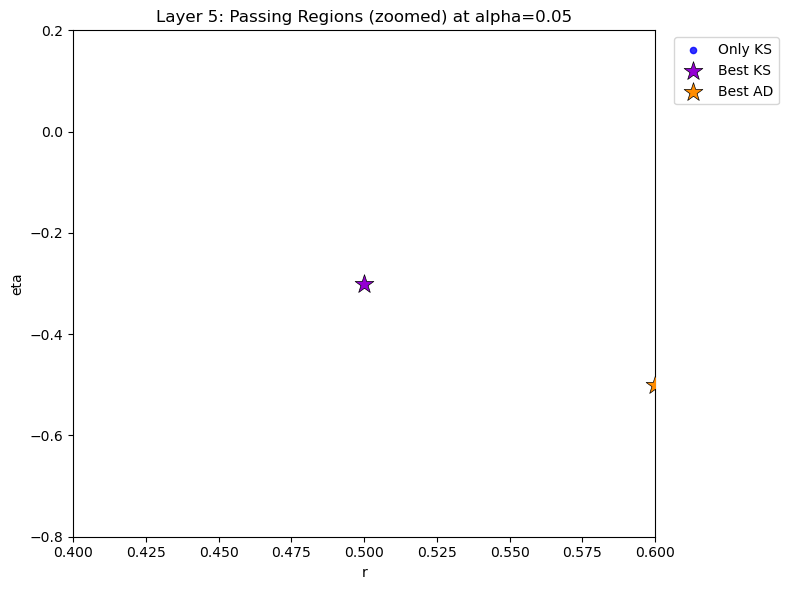

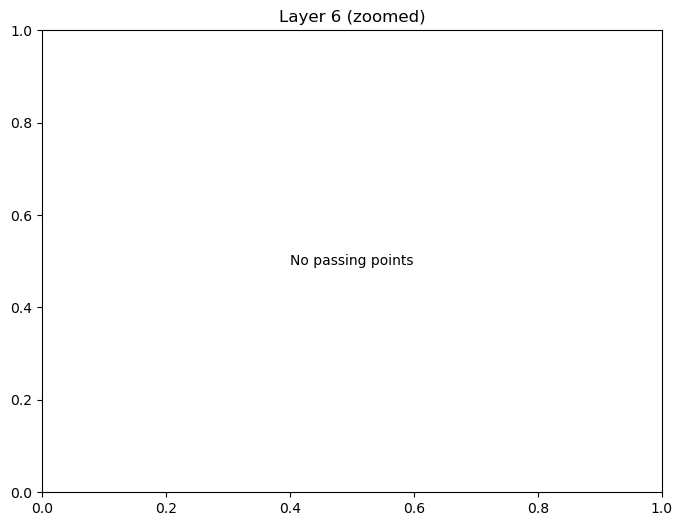

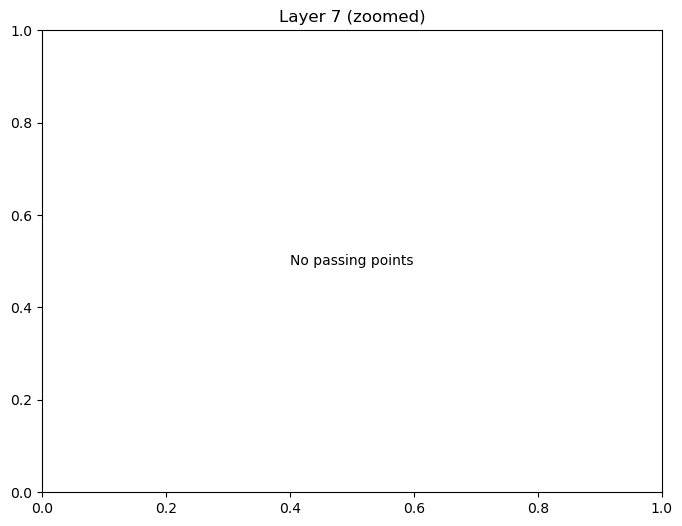

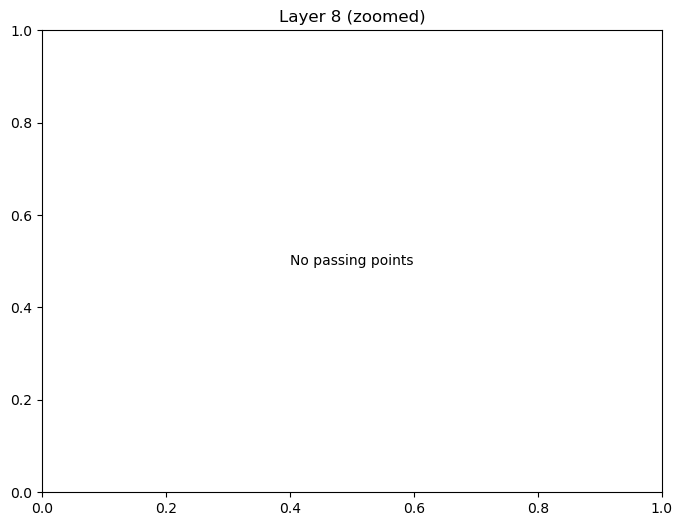

In [11]:
for group in common_groups:
    fig, ax = plt.subplots(figsize=(8, 6))
    merged = group_results[group]
    passing = merged[merged['pass_summary'] != 'Neither']
    
    if len(passing) == 0:
        ax.text(0.5, 0.5, 'No passing points', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{GROUP.capitalize()} {group} (zoomed)')
        plt.show()
        continue
    
    for cat in ['Only AD', 'Only KS', 'Both']:
        subset = passing[passing['pass_summary'] == cat]
        if len(subset) > 0:
            ax.scatter(subset['r'], subset['eta'], s=20, c=palette[cat], label=cat, alpha=0.8)
    
    ks_best = merged.loc[merged['best_ksstat'].idxmin()]
    ad_best = merged.loc[merged['best_adstat'].idxmin()]
    ax.scatter([ks_best['r']], [ks_best['eta']], marker='*', s=200, c='darkviolet', 
               edgecolors='black', linewidths=0.5, zorder=5, label='Best KS')
    ax.scatter([ad_best['r']], [ad_best['eta']], marker='*', s=200, c='darkorange', 
               edgecolors='black', linewidths=0.5, zorder=5, label='Best AD')
    
    r_pad = max(0.1, (passing['r'].max() - passing['r'].min()) * 0.15)
    eta_pad = max(0.5, (passing['eta'].max() - passing['eta'].min()) * 0.15)
    ax.set_xlim(passing['r'].min() - r_pad, passing['r'].max() + r_pad)
    ax.set_ylim(passing['eta'].min() - eta_pad, passing['eta'].max() + eta_pad)
    
    ax.set_xlabel('r')
    ax.set_ylabel('eta')
    ax.set_title(f'{GROUP.capitalize()} {group}: Passing Regions (zoomed) at alpha={alpha}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    plt.show()

## KS vs AD Stat Correlation

Scatter of KS stat vs AD stat at each (r, eta) point — shows how the two test statistics relate across the parameter space.

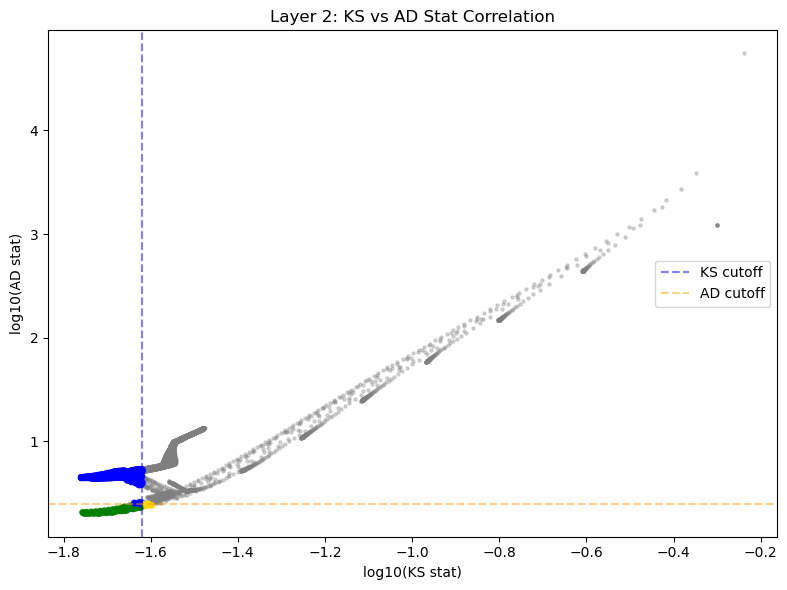

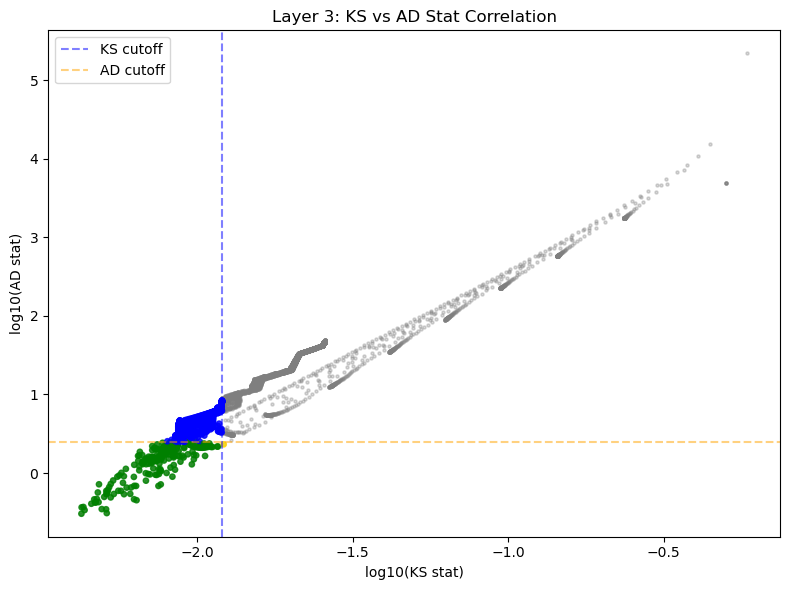

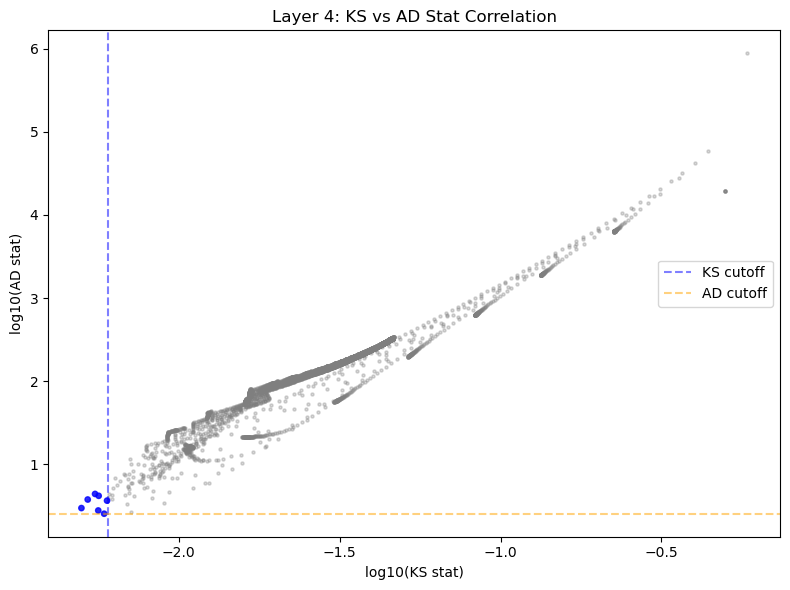

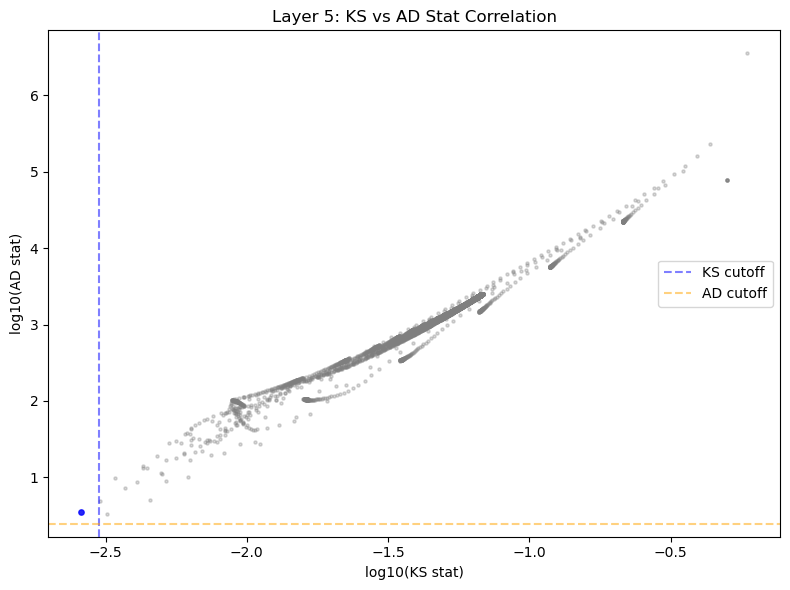

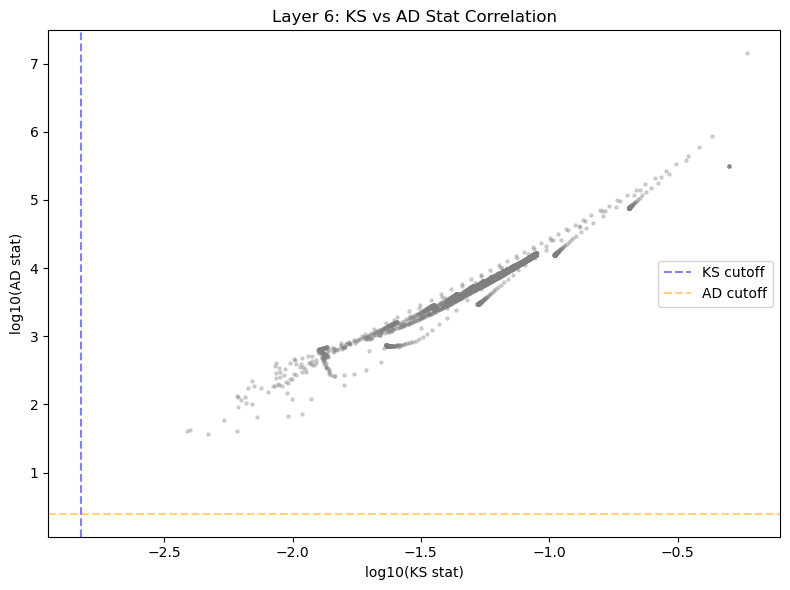

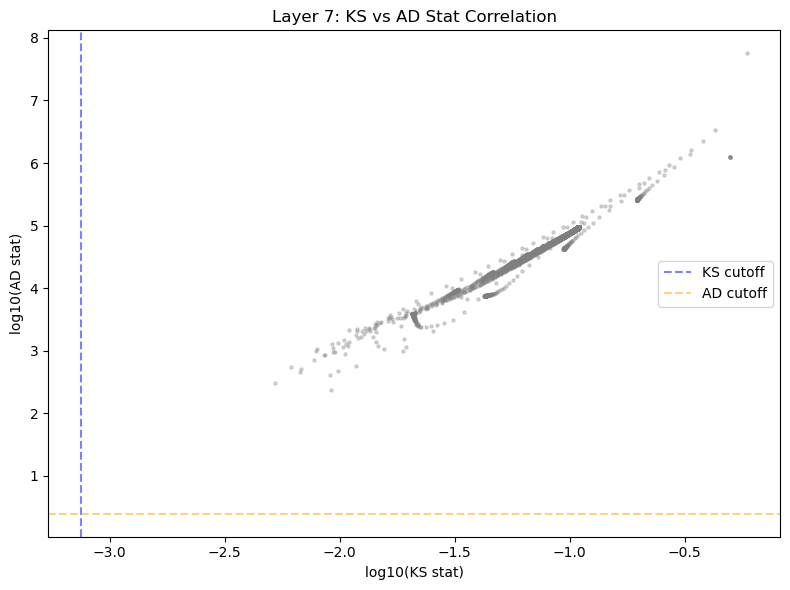

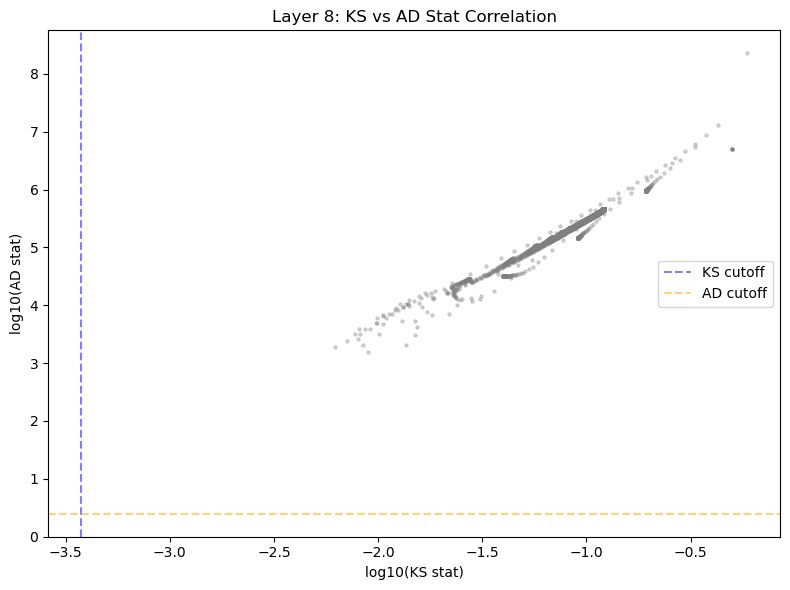

In [12]:
for group in common_groups:
    fig, ax = plt.subplots(figsize=(8, 6))
    merged = group_results[group]
    n = group_total_samples[group]
    ks_cutoff = stats.kstwo.isf(alpha, n)
    
    ax.scatter(np.log10(merged['best_ksstat']), np.log10(merged['best_adstat']), 
               s=5, alpha=0.3, c='tab:gray')
    
    passing = merged[merged['pass_summary'] != 'Neither']
    if len(passing) > 0:
        colors = passing['pass_summary'].map(palette)
        ax.scatter(np.log10(passing['best_ksstat']), np.log10(passing['best_adstat']),
                   s=15, c=colors, alpha=0.8)
    
    ax.axvline(np.log10(ks_cutoff), c='blue', ls='--', alpha=0.5, label='KS cutoff')
    ax.axhline(np.log10(ad_cutoff), c='orange', ls='--', alpha=0.5, label='AD cutoff')
    
    ax.set_xlabel('log10(KS stat)')
    ax.set_ylabel('log10(AD stat)')
    ax.set_title(f'{GROUP.capitalize()} {group}: KS vs AD Stat Correlation')
    ax.legend()
    fig.tight_layout()
    plt.show()

## Aggregate Overlap Across All Groups

Jaccard index bar chart and overall statistics.

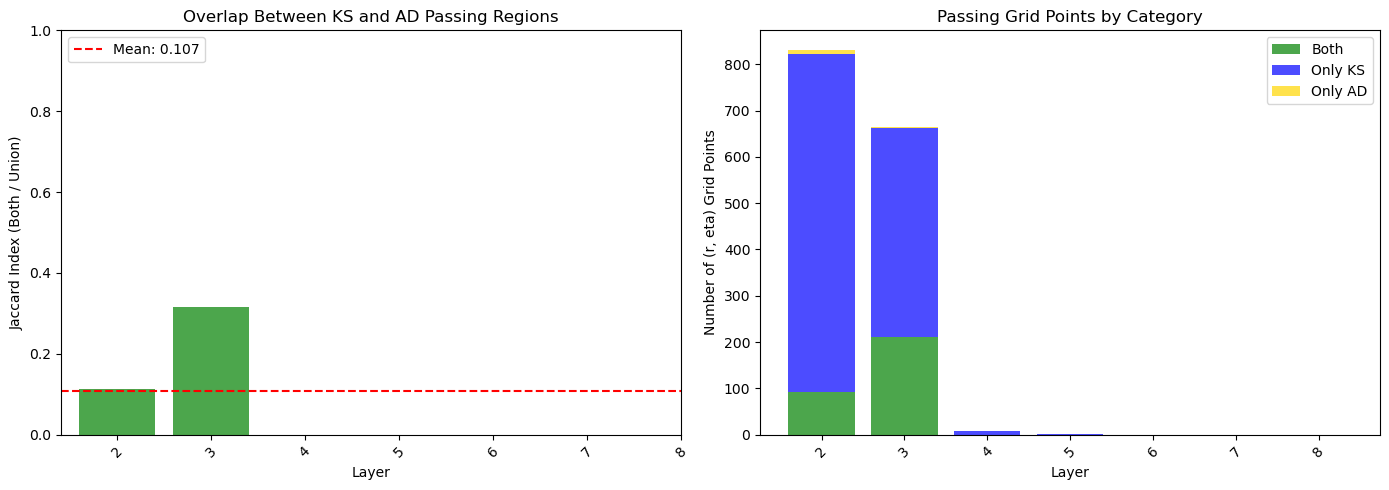


Overall: 303/1504 union points pass both tests (Jaccard = 0.201)
Mean Euclidean distance between best KS and best AD points: 0.976


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Jaccard index bar chart
ax1.bar(range(len(common_groups)), summary_df['Jaccard (Both/Union)'], color='green', alpha=0.7)
ax1.set_xticks(range(len(common_groups)))
ax1.set_xticklabels([str(g) for g in common_groups], rotation=45)
ax1.set_xlabel(GROUP.capitalize())
ax1.set_ylabel('Jaccard Index (Both / Union)')
ax1.set_title('Overlap Between KS and AD Passing Regions')
ax1.set_ylim(0, 1)
ax1.axhline(summary_df['Jaccard (Both/Union)'].mean(), c='red', ls='--', 
            label=f"Mean: {summary_df['Jaccard (Both/Union)'].mean():.3f}")
ax1.legend()

# Stacked bar chart of pass categories
categories = ['Both', 'Only KS', 'Only AD']
colors = ['green', 'blue', 'gold']
bottoms = np.zeros(len(common_groups))
for cat, color in zip(categories, colors):
    vals = summary_df[cat].values
    ax2.bar(range(len(common_groups)), vals, bottom=bottoms, color=color, alpha=0.7, label=cat)
    bottoms += vals

ax2.set_xticks(range(len(common_groups)))
ax2.set_xticklabels([str(g) for g in common_groups], rotation=45)
ax2.set_xlabel(GROUP.capitalize())
ax2.set_ylabel('Number of (r, eta) Grid Points')
ax2.set_title('Passing Grid Points by Category')
ax2.legend()

fig.tight_layout()
plt.show()

# Overall stats
total_both = summary_df['Both'].sum()
total_union = summary_df['Union'].sum()
print(f"\nOverall: {total_both}/{total_union} union points pass both tests "
      f"(Jaccard = {total_both/total_union:.3f})" if total_union > 0 else "\nNo passing points found.")
print(f"Mean Euclidean distance between best KS and best AD points: {param_comparison['euclidean_dist'].mean():.3f}")

## Per-Group Comparison: Zoomed r-eta Region + AD Fit + KS Fit

For each group, 3 rows:
1. Zoomed r-eta pass/fail scatter (same as above)
2. AD-optimal fit: empirical vs computed CDF, PDF, log PDF
3. KS-optimal fit: empirical vs computed CDF, PDF, log PDF

In [16]:
# Load plotting utilities and sample data
os.chdir(os.path.join(ROOT_DIR, 'utilities'))
from plotting import visualize_cdf_pdf
from testing import compute_prior_cdf
os.chdir(os.path.join(ROOT_DIR, 'anderson-darling', 'ks-ad-comparisons'))

group_data_map = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}.pickle'))

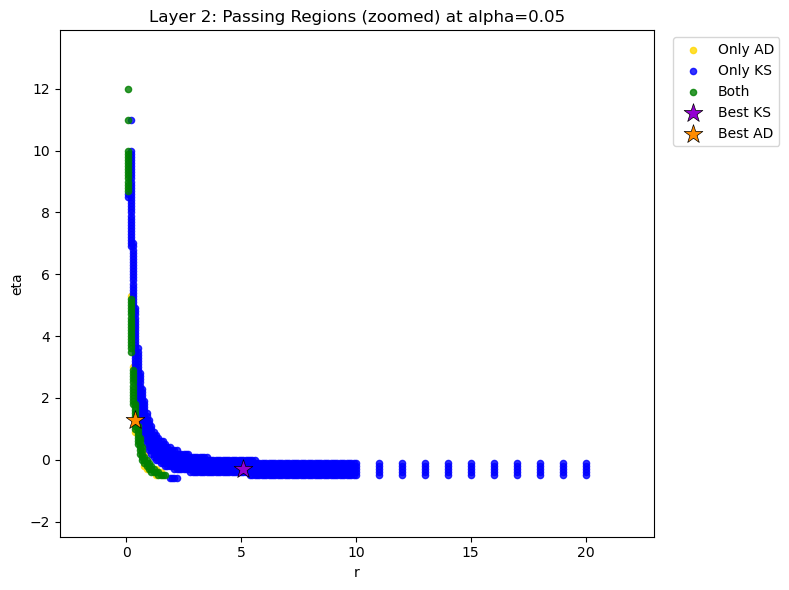

Layer 2 — AD-optimal: r=0.4, eta=1.3, scale=13.734, KS stat=0.017908


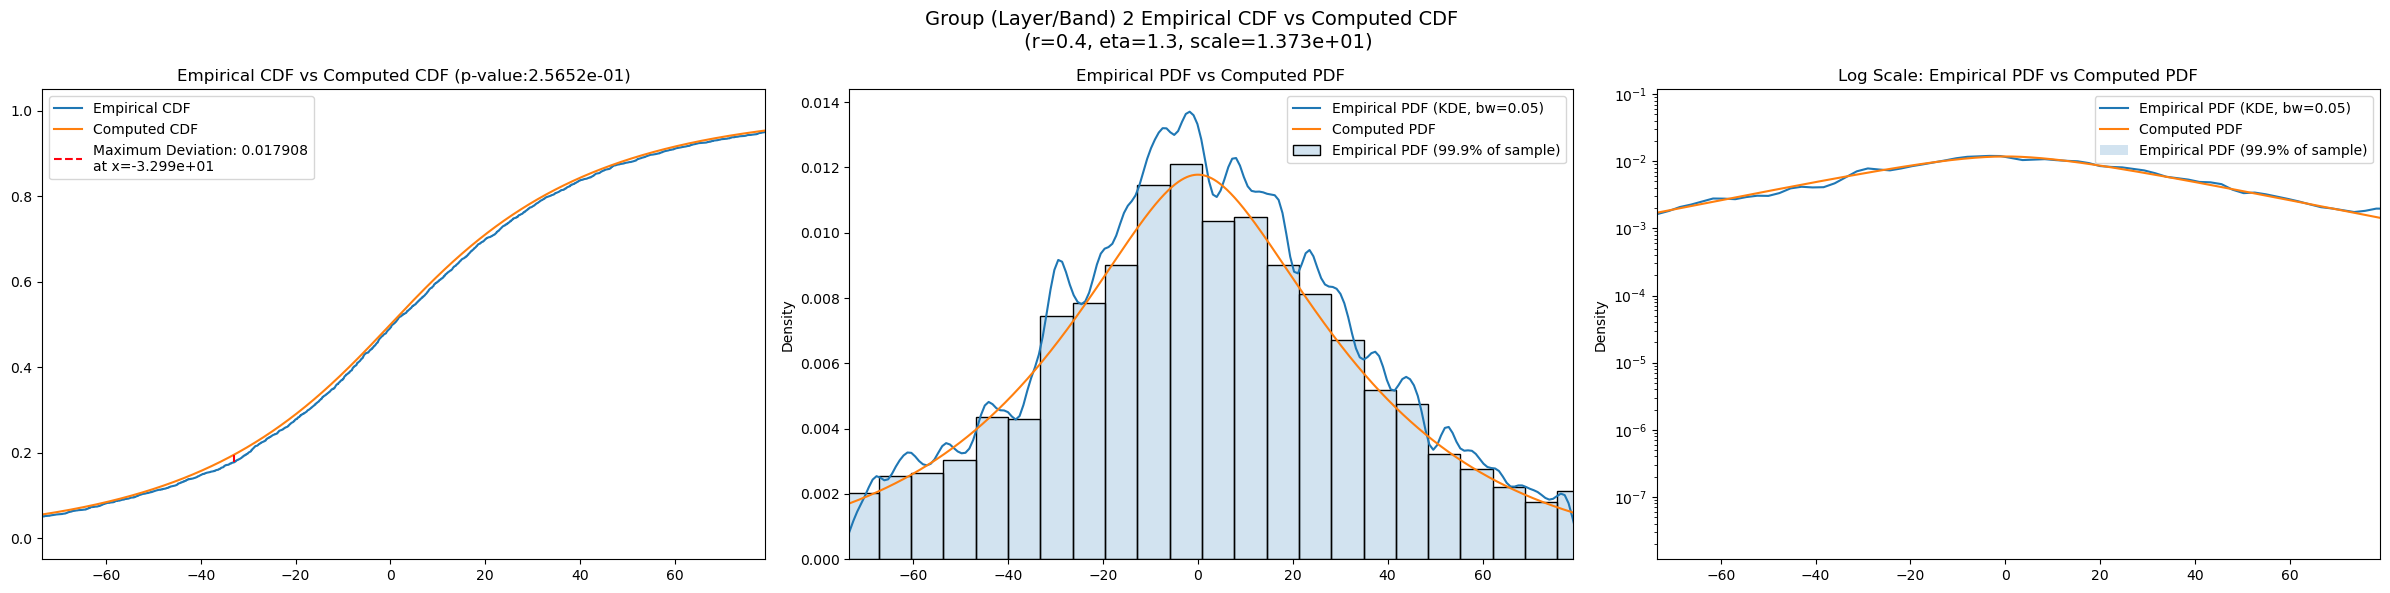

Layer 2 — KS-optimal: r=5.0, eta=-0.32, scale=3437.49, KS stat=0.017339


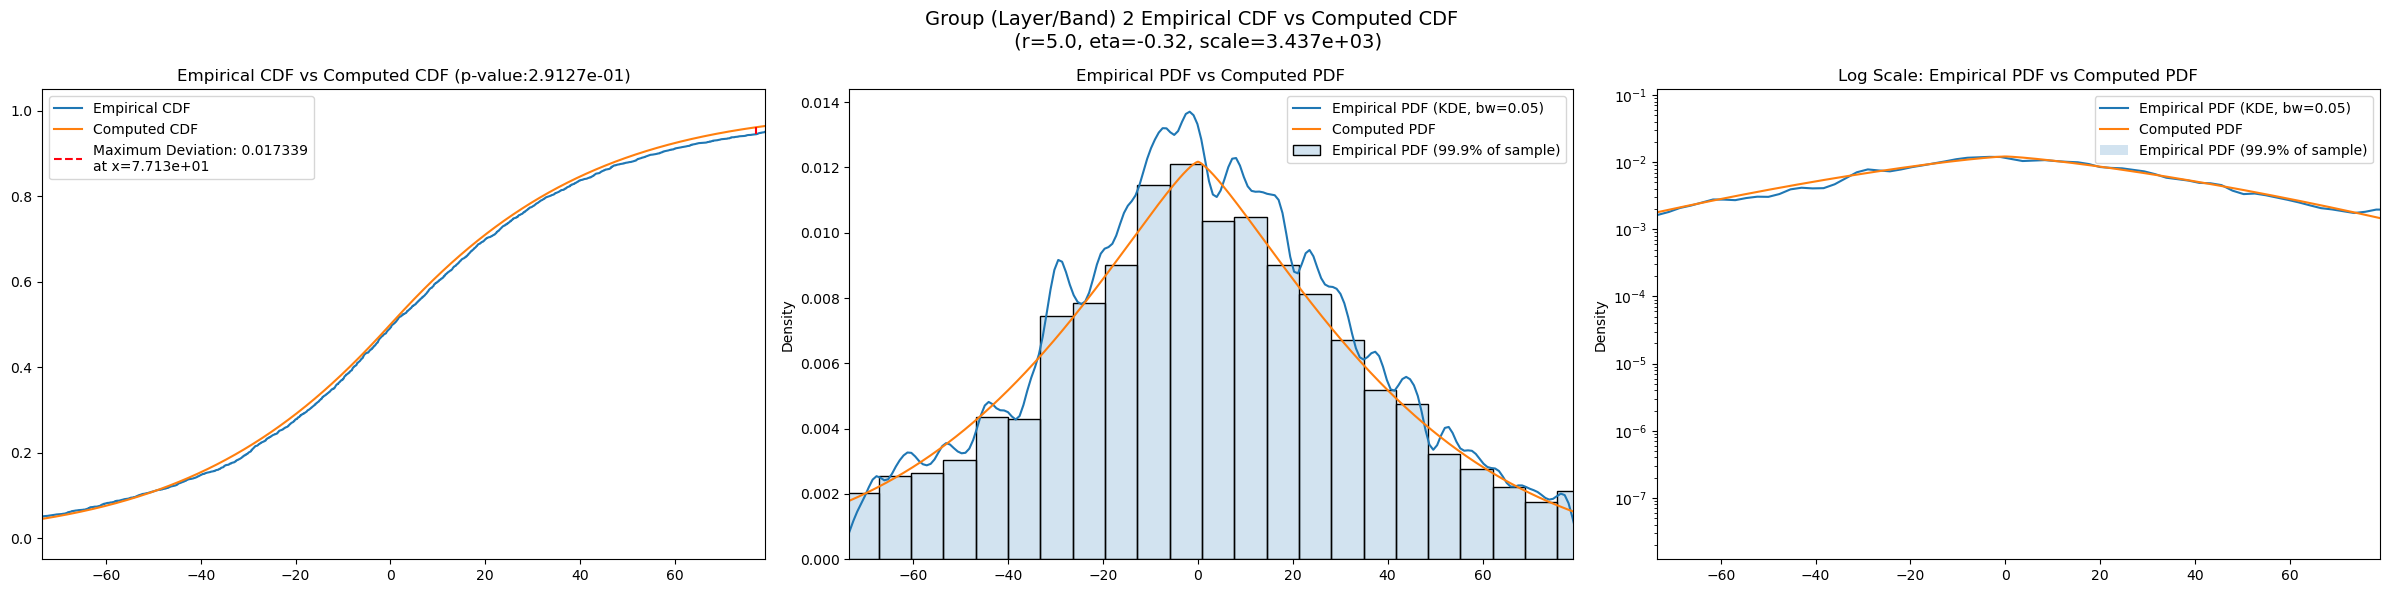

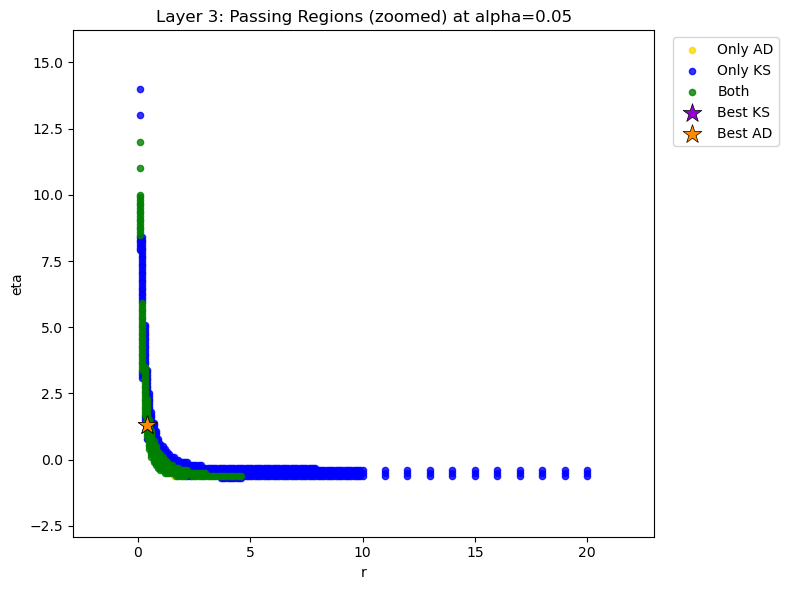

Layer 3 — AD-optimal: r=0.46, eta=0.9, scale=16.1599, KS stat=0.004813


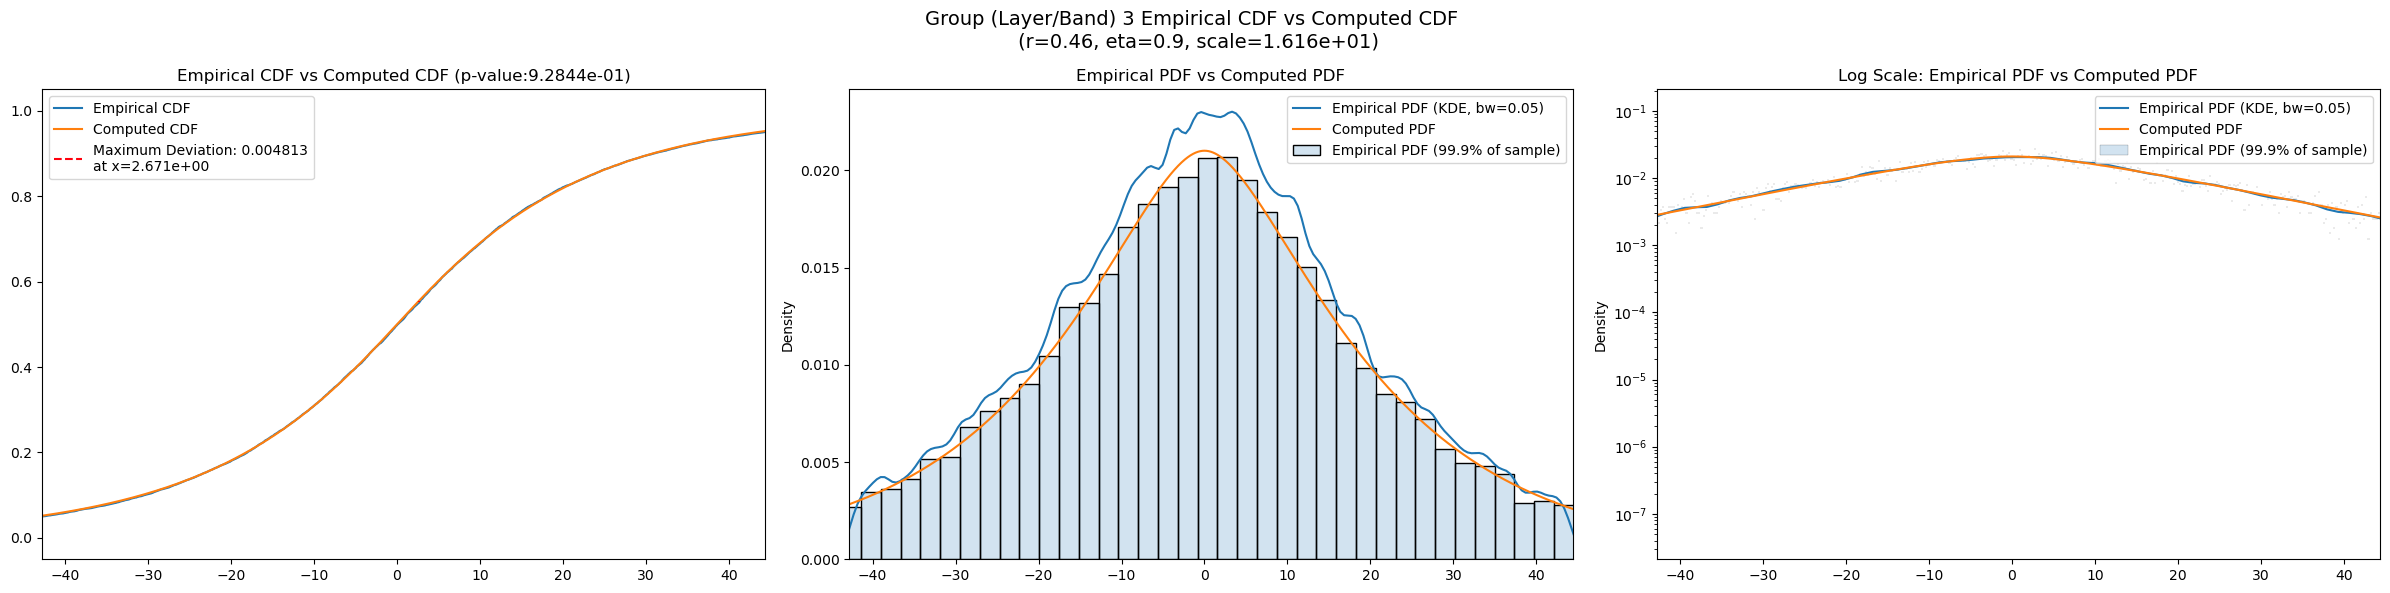

Layer 3 — KS-optimal: r=0.38, eta=1.5, scale=2.47932, KS stat=0.004103


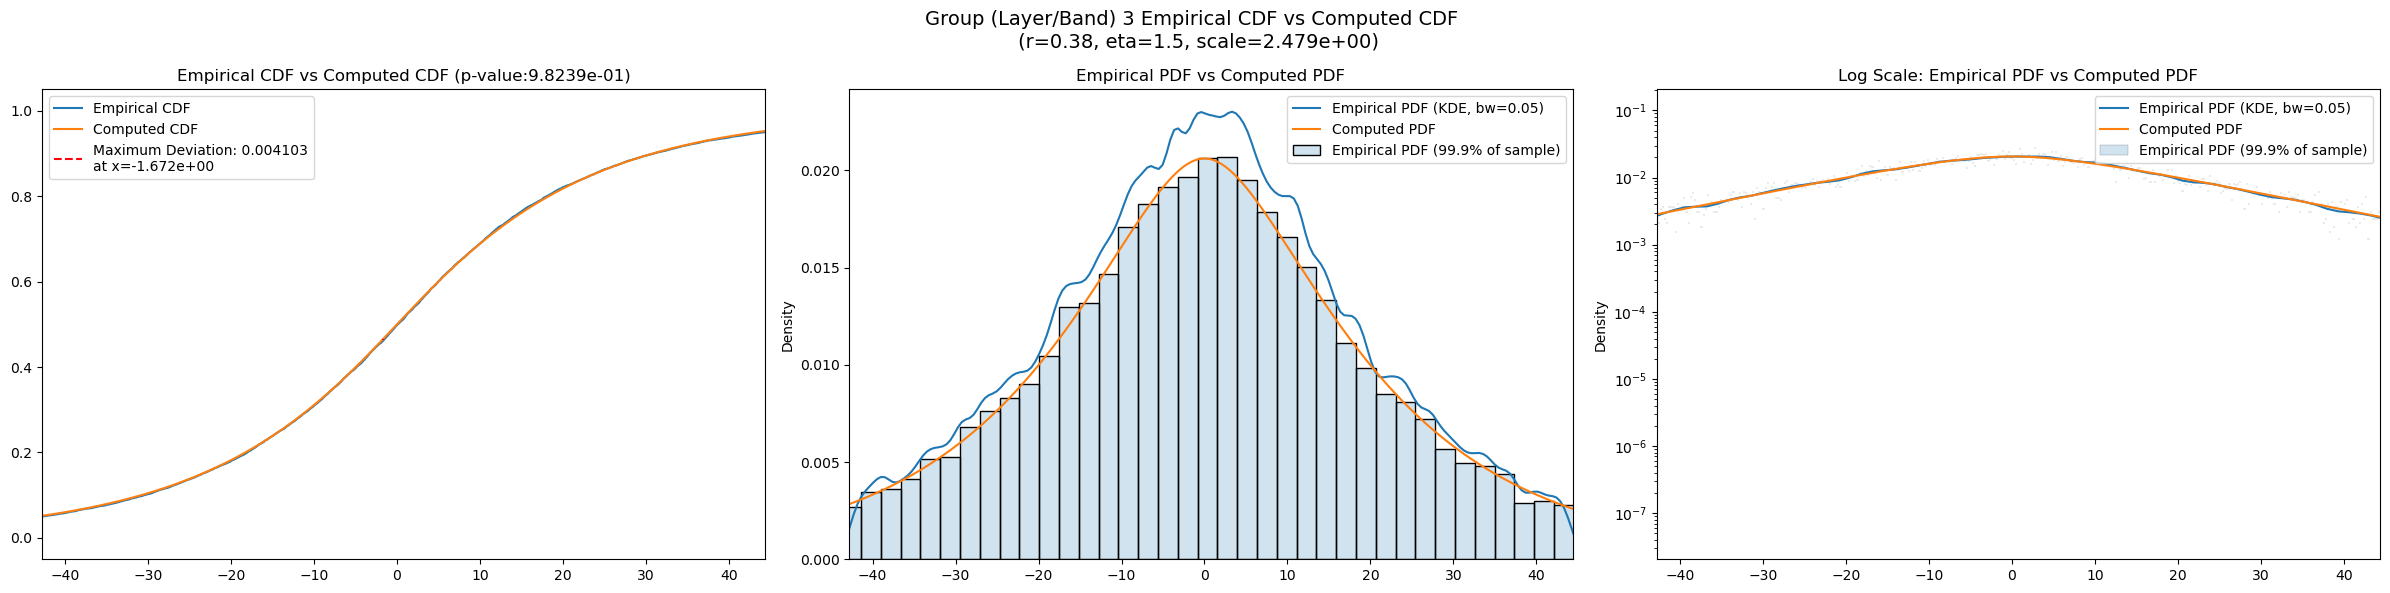

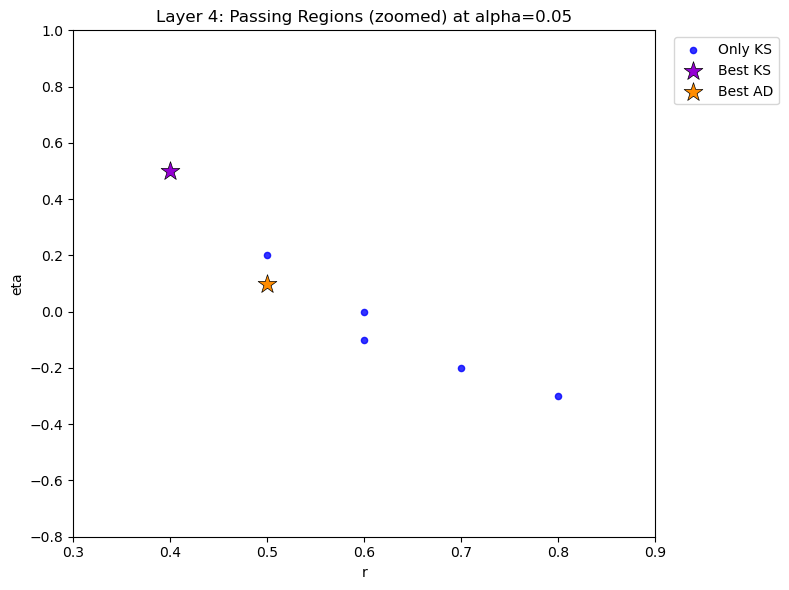

Layer 4 — AD-optimal: r=0.58, eta=-0.1, scale=35.8929, KS stat=0.006426


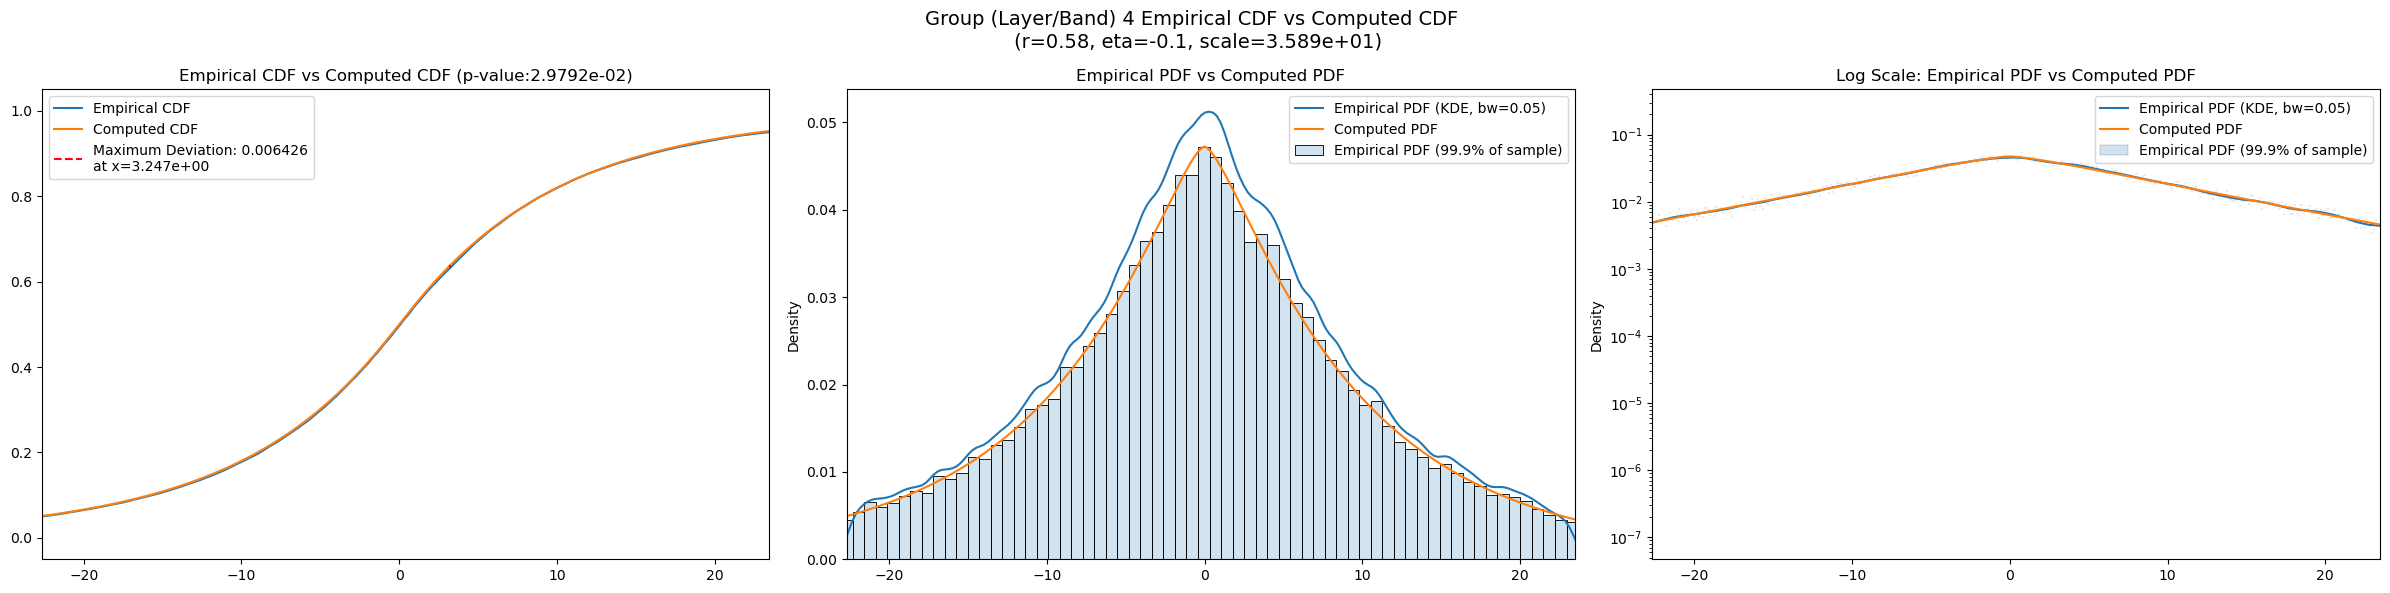

Layer 4 — KS-optimal: r=0.42, eta=0.4, scale=4.08611, KS stat=0.004938


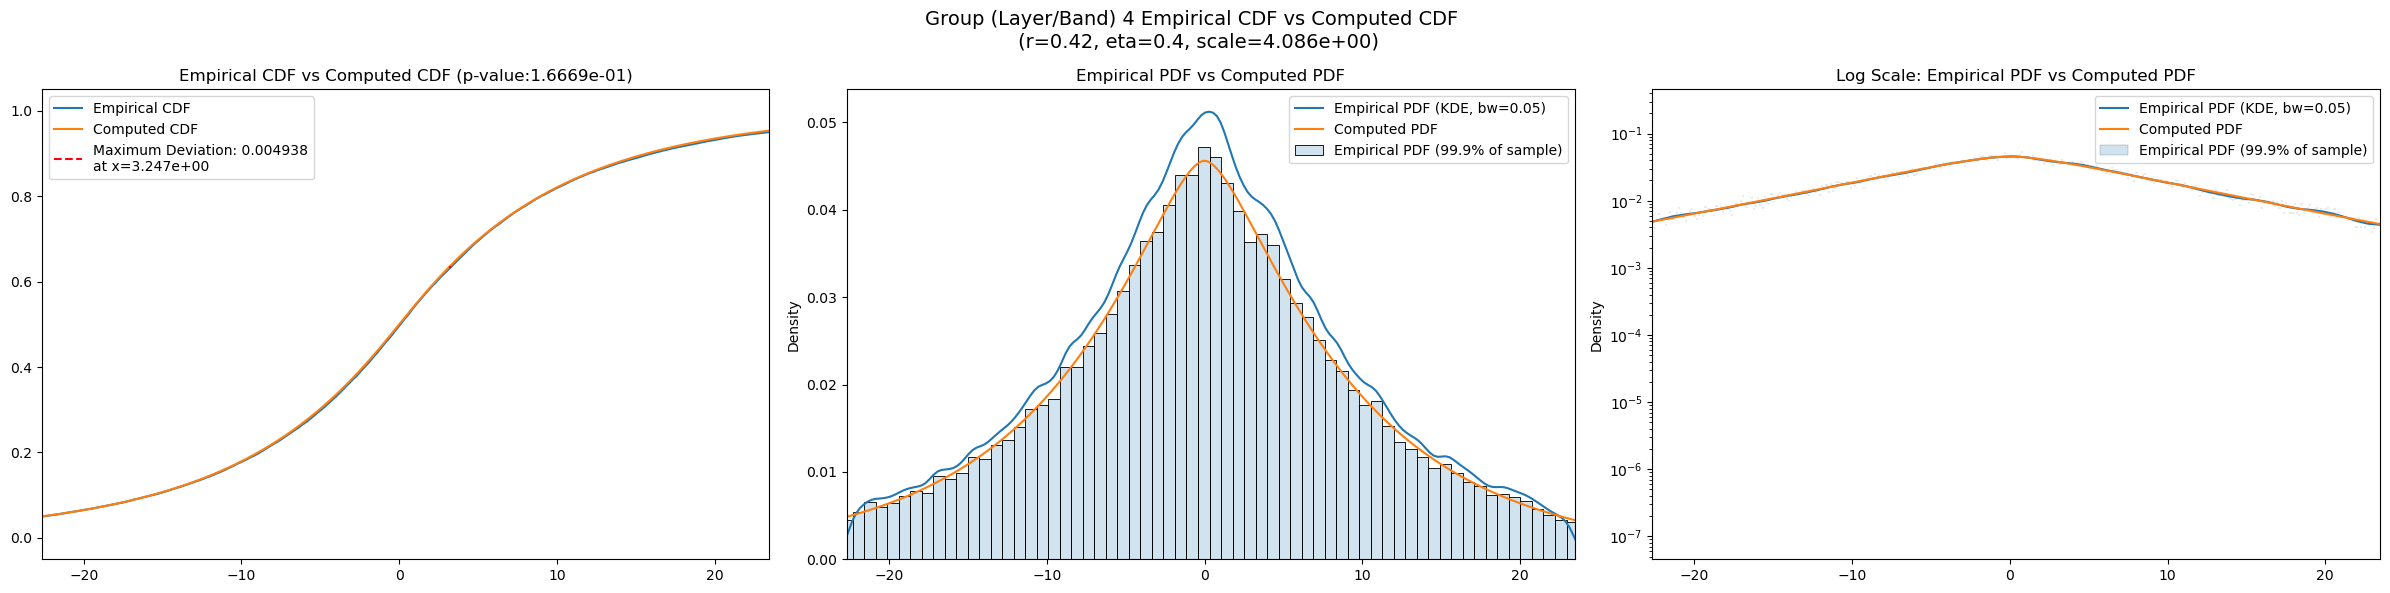

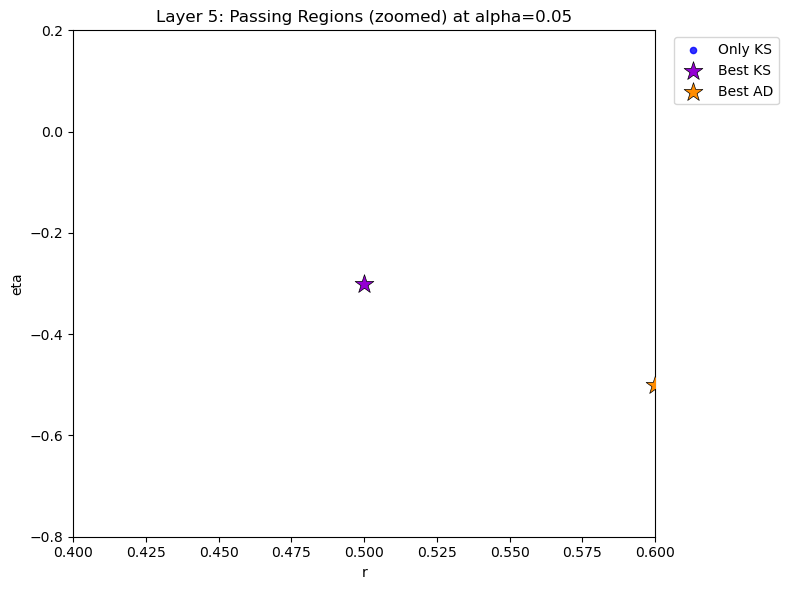

Layer 5 — AD-optimal: r=0.5, eta=-0.34, scale=6.14472, KS stat=0.002296


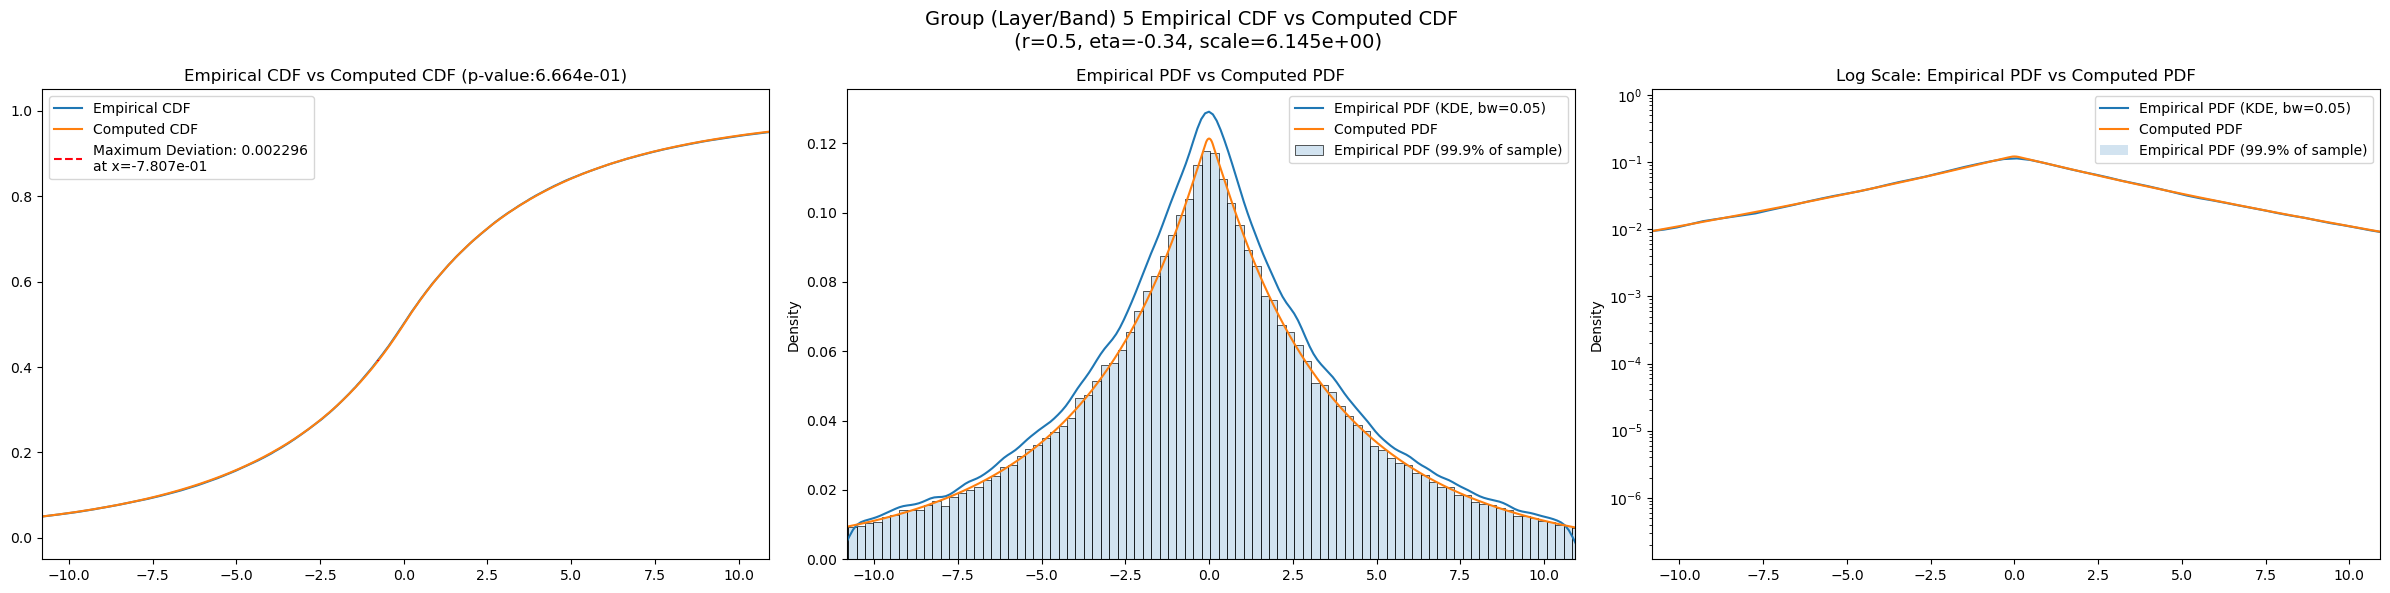

Layer 5 — KS-optimal: r=0.5, eta=-0.33, scale=6.05572, KS stat=0.001851


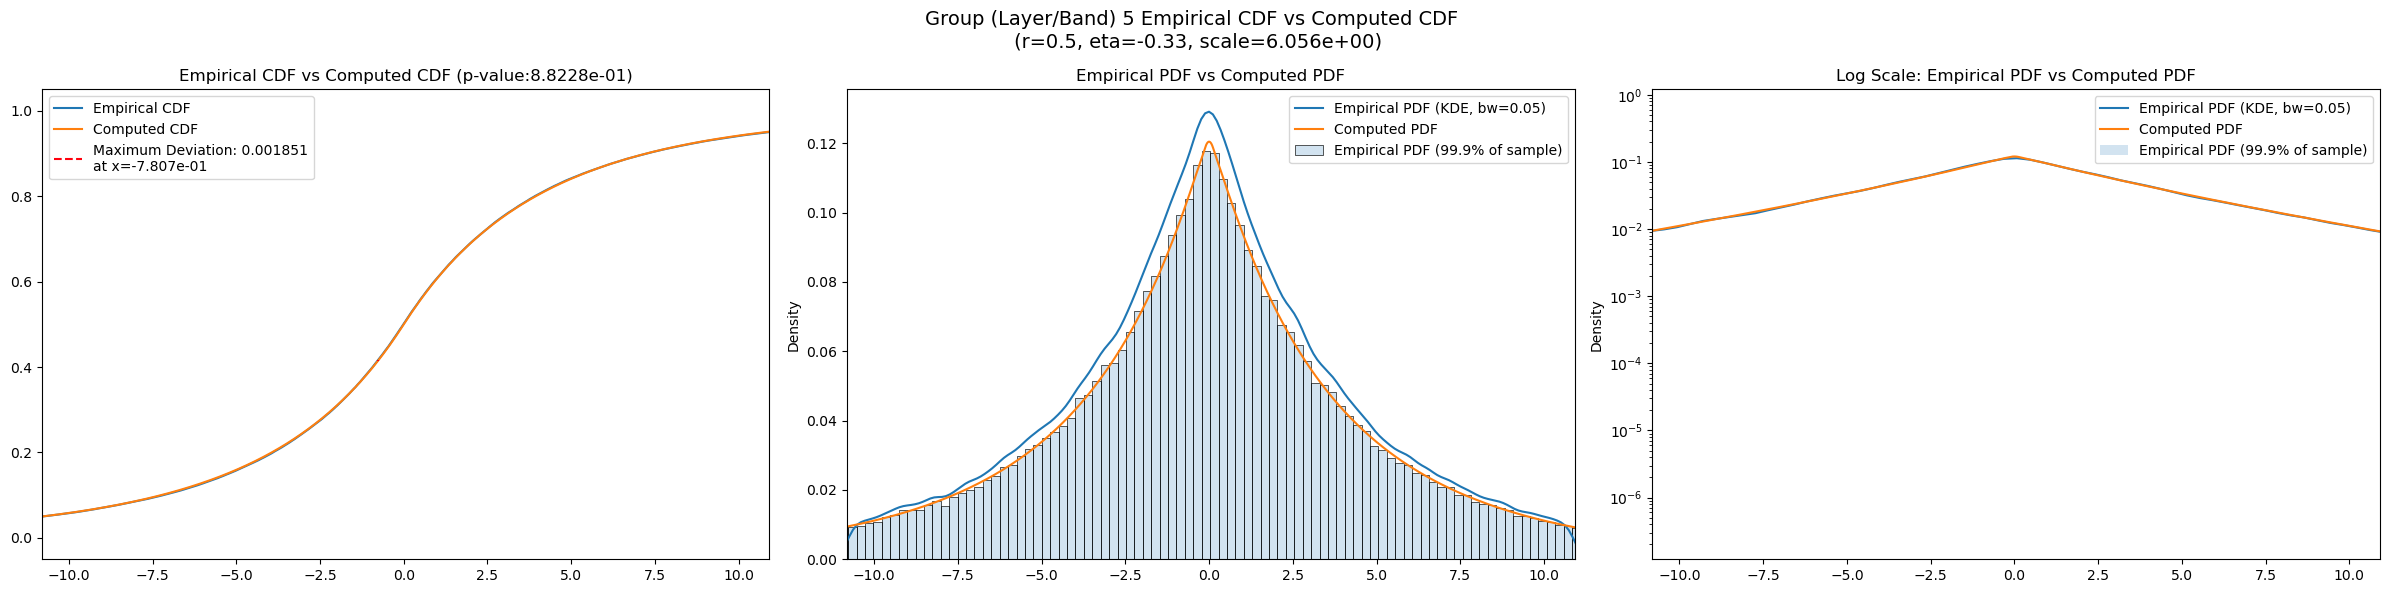

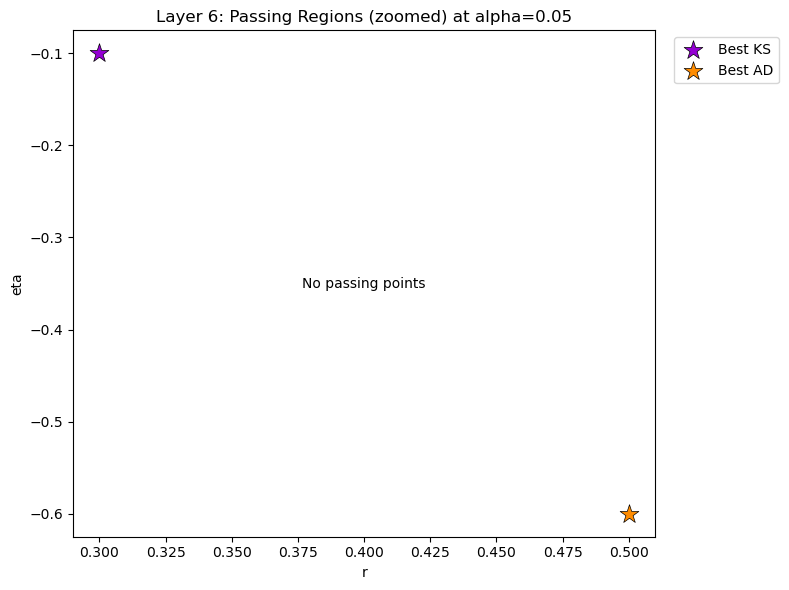

Layer 6 — AD-optimal: r=0.42, eta=-0.5, scale=0.680293, KS stat=0.004368


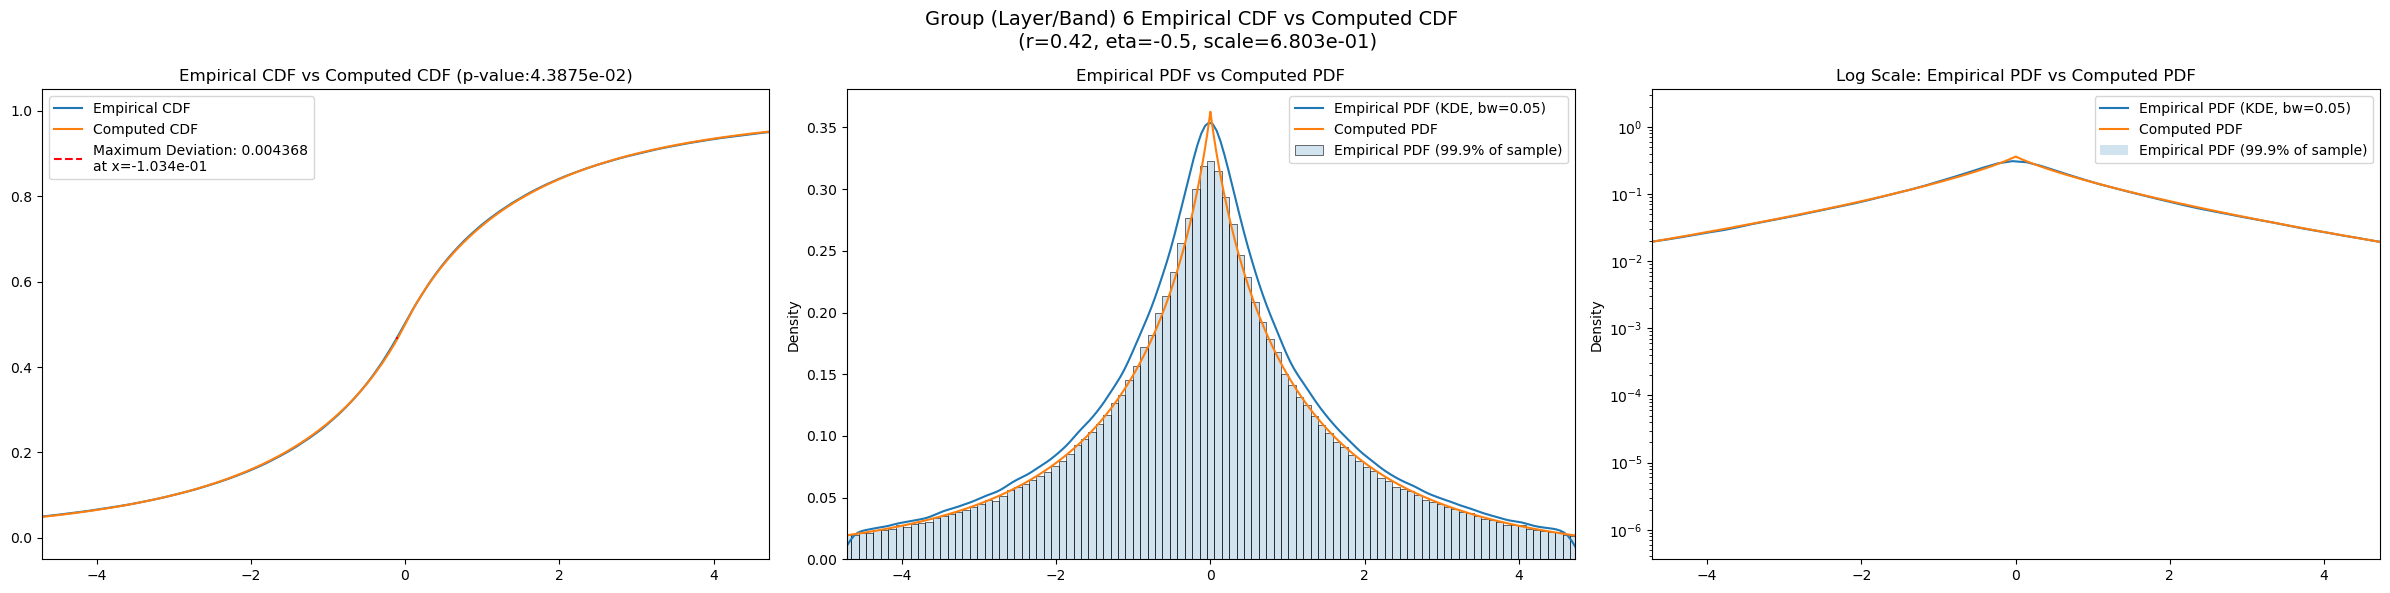

Layer 6 — KS-optimal: r=0.35, eta=-0.3, scale=0.146151, KS stat=0.003292


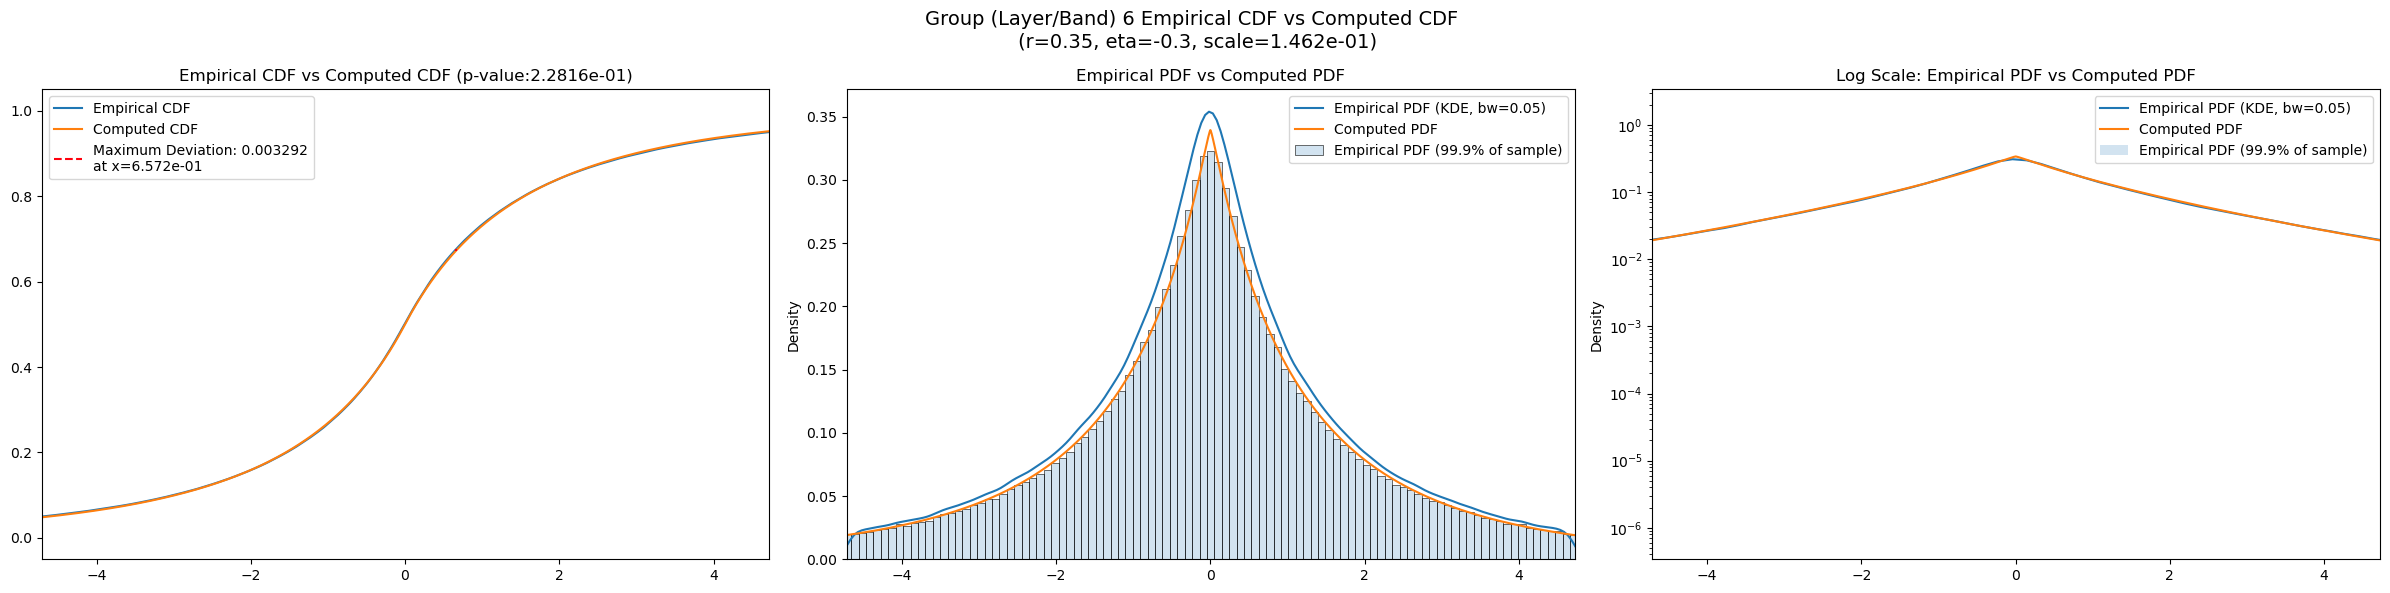

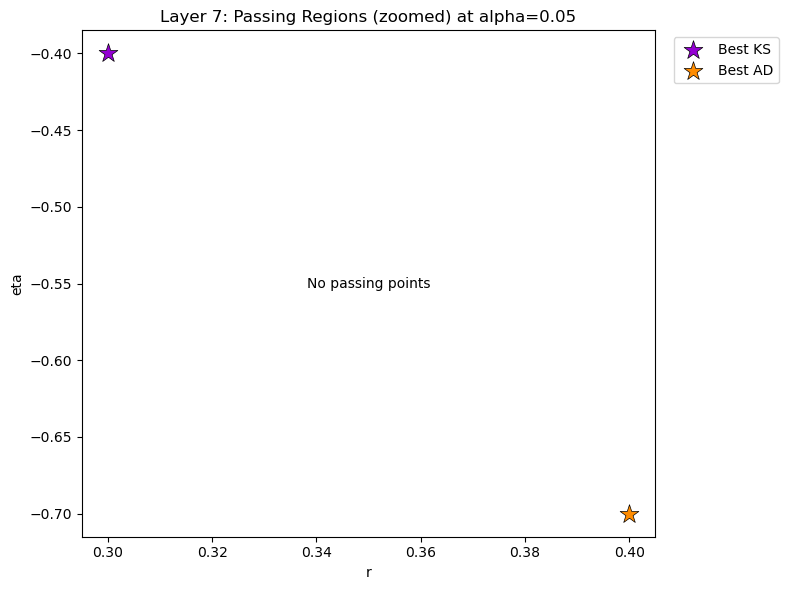

Layer 7 — AD-optimal: r=0.35, eta=-0.6, scale=0.0514148, KS stat=0.008289


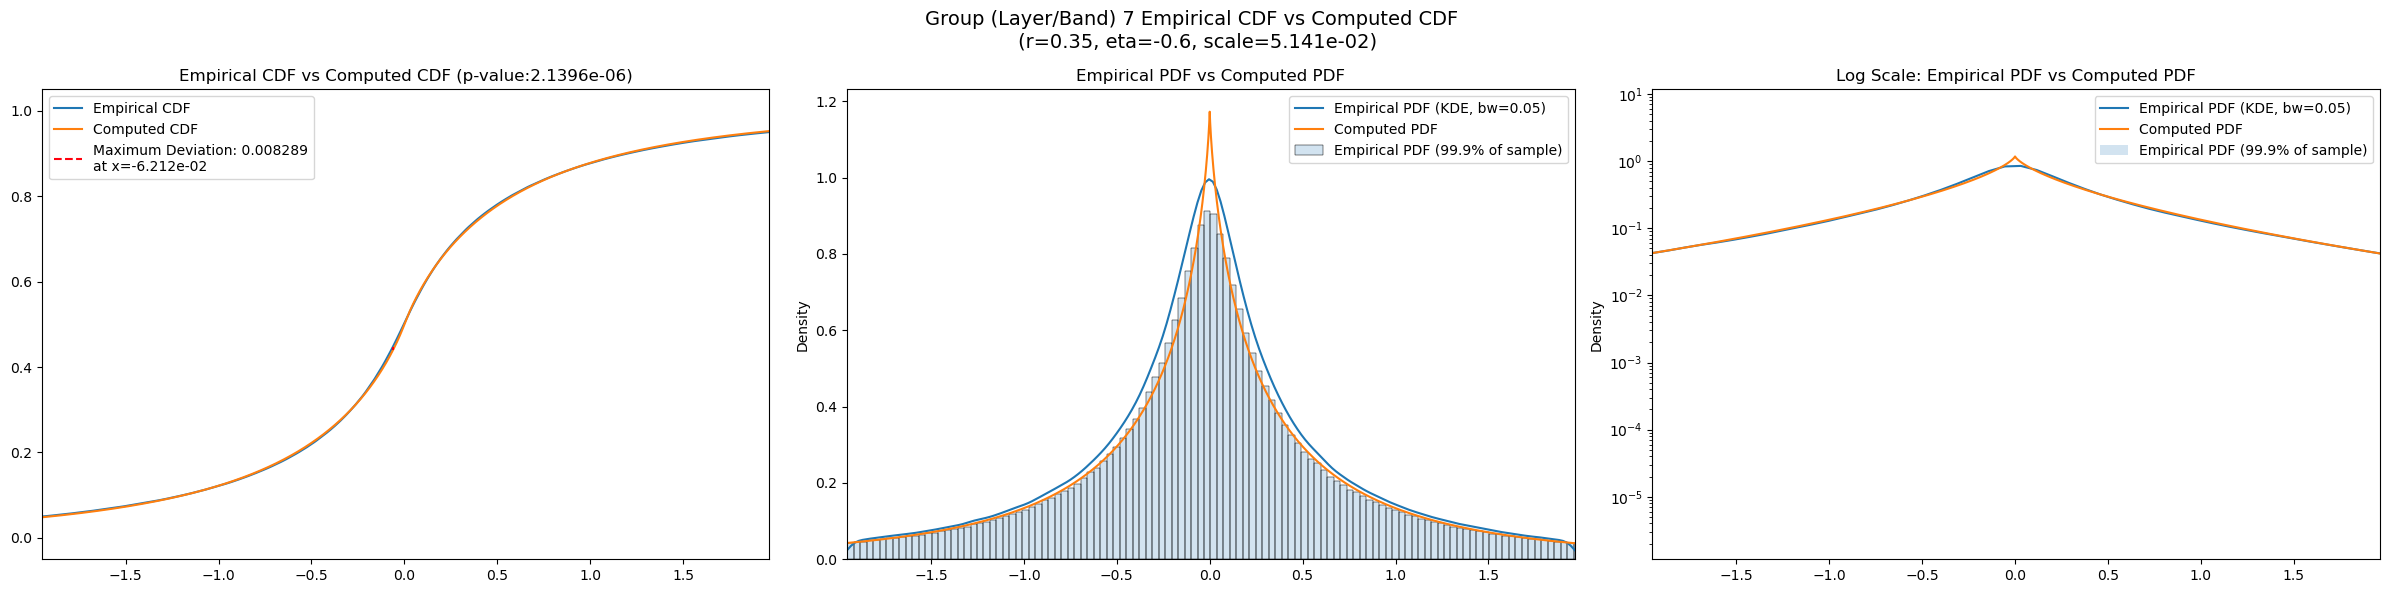

Layer 7 — KS-optimal: r=0.25, eta=-0.2, scale=0.000900869, KS stat=0.005021


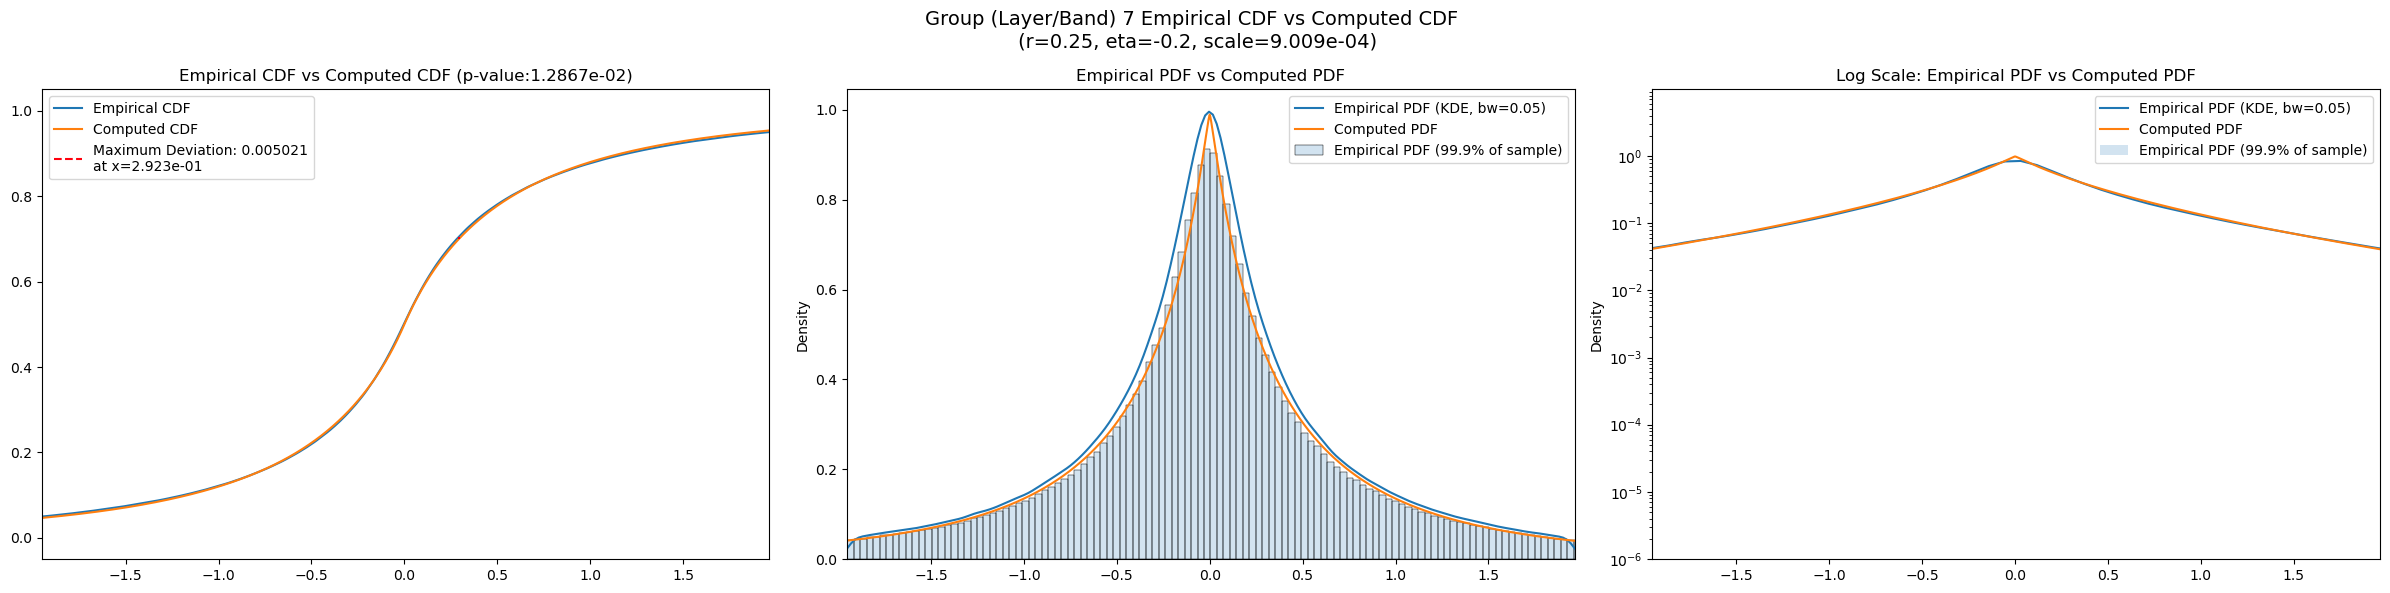

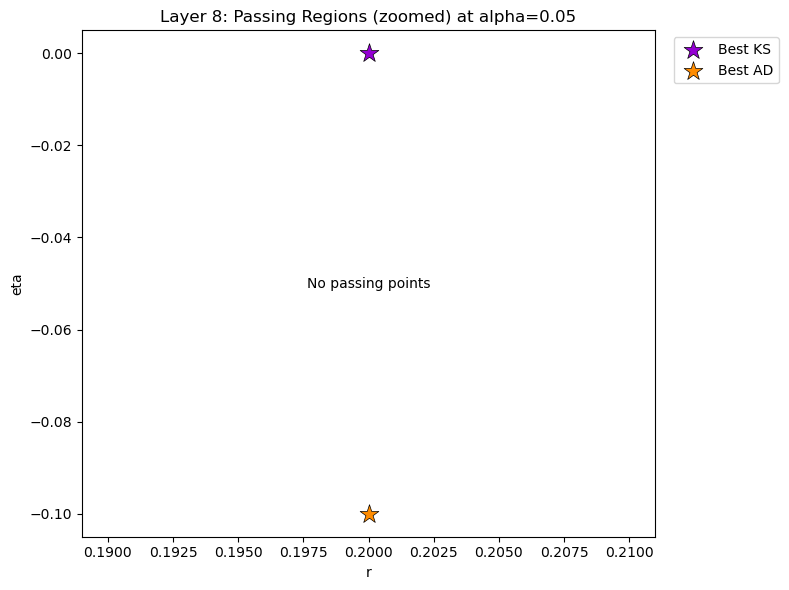

Layer 8 — AD-optimal: r=0.22, eta=-0.2, scale=2.63736e-05, KS stat=0.007726


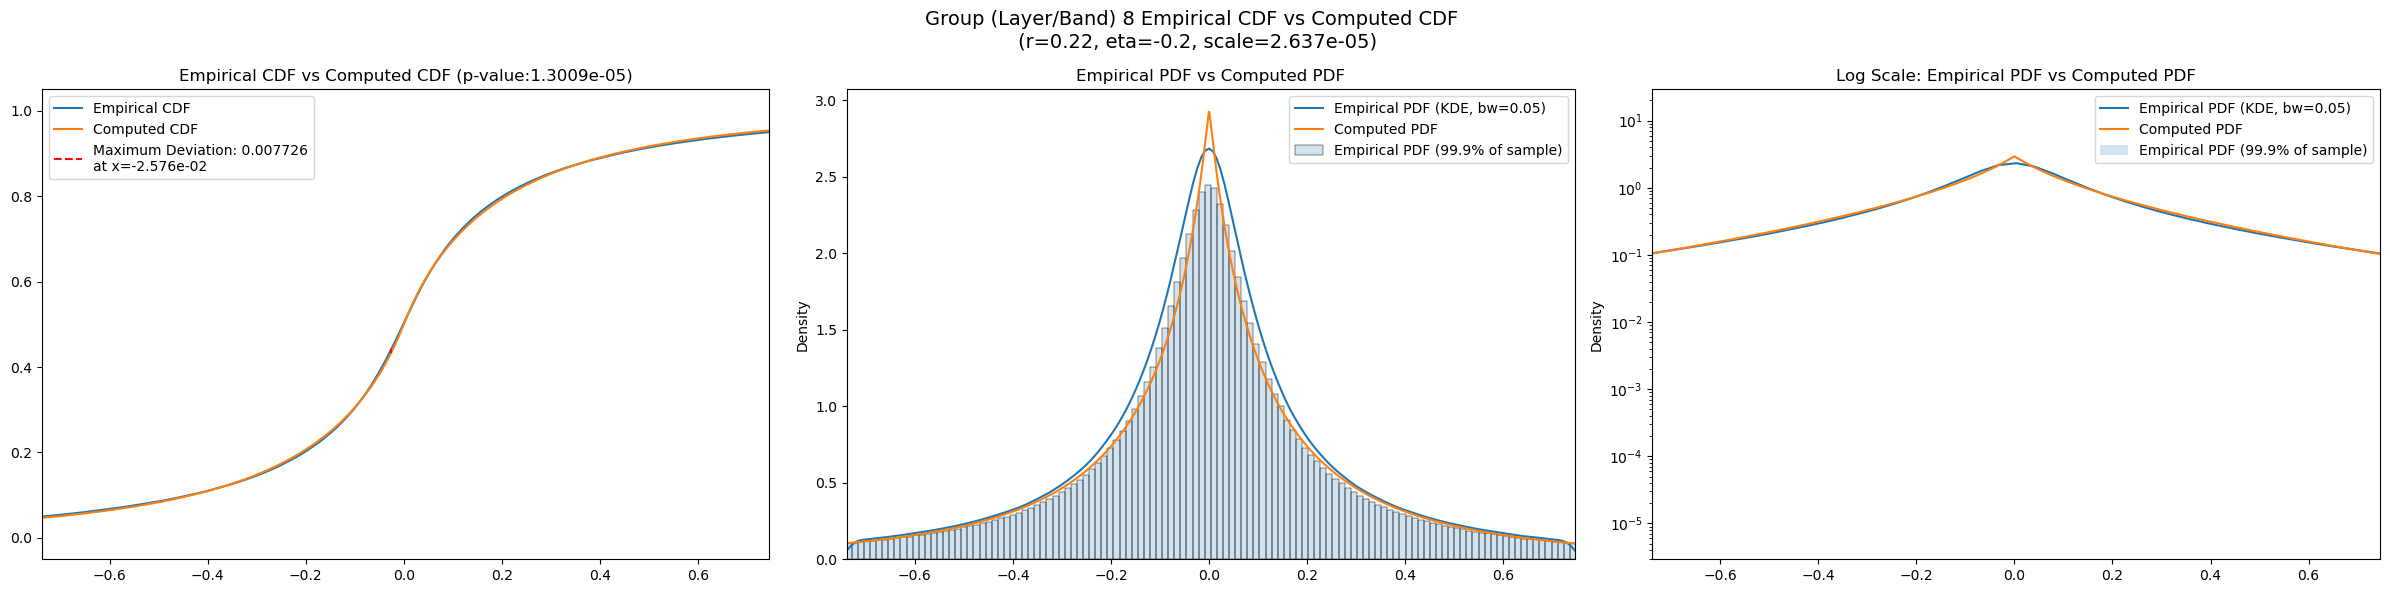

Layer 8 — KS-optimal: r=0.2, eta=-0.01, scale=3.52066e-06, KS stat=0.006170


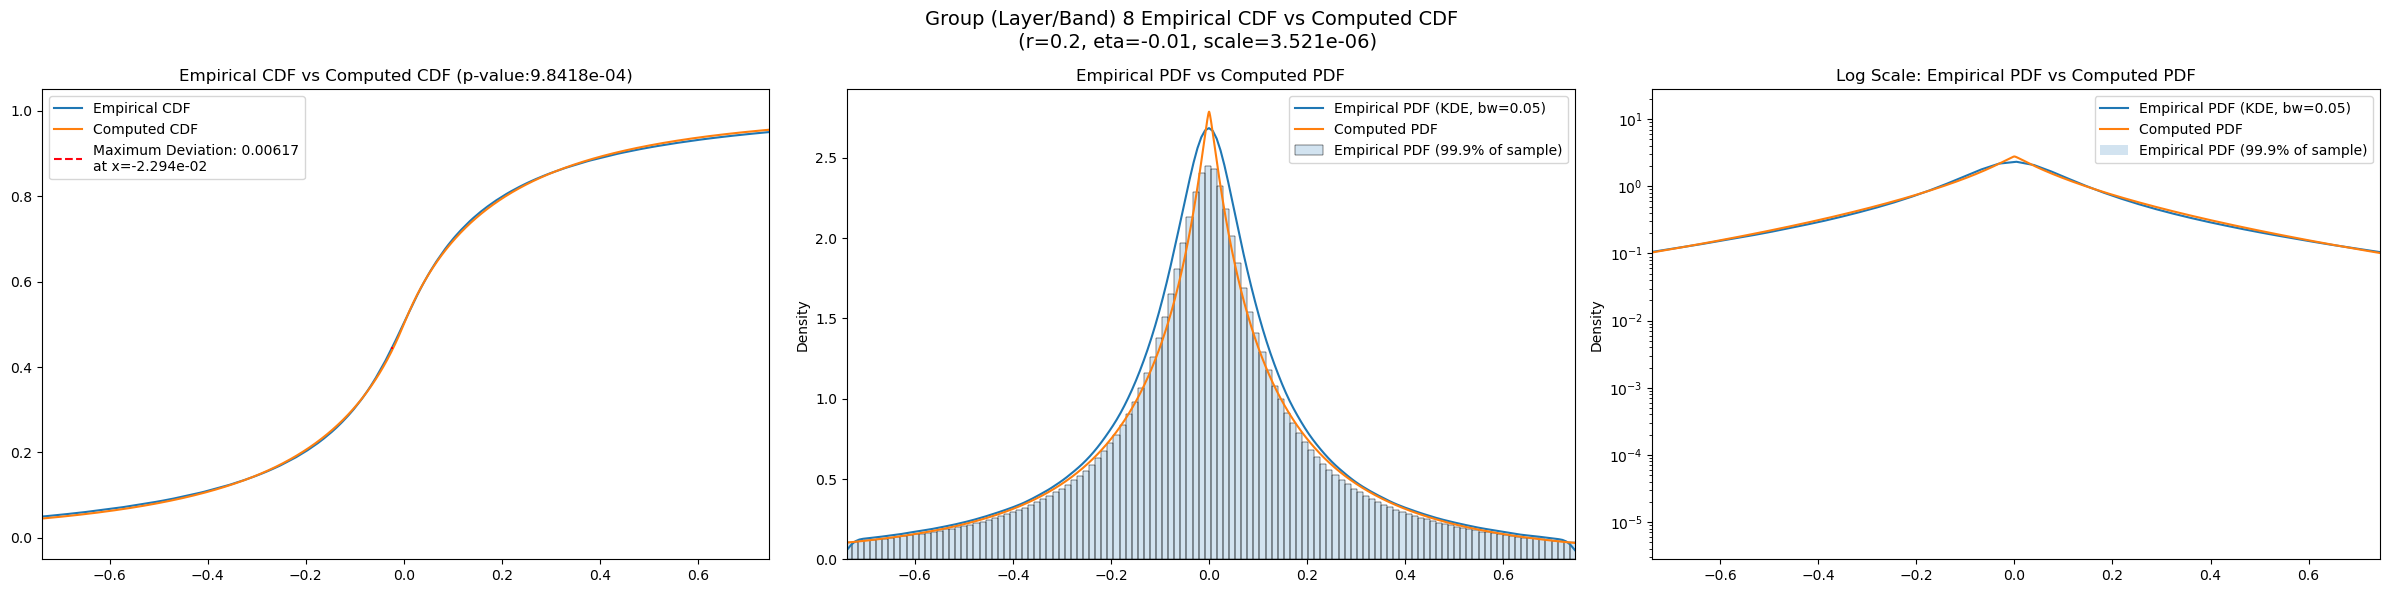

In [17]:
for group in common_groups:
    merged = group_results[group]
    passing = merged[merged['pass_summary'] != 'Neither']
    sample = group_data_map[group]

    # --- Row 1: Zoomed r-eta plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    if len(passing) == 0:
        ax.text(0.5, 0.5, 'No passing points', ha='center', va='center', transform=ax.transAxes)
    else:
        for cat in ['Only AD', 'Only KS', 'Both']:
            subset = passing[passing['pass_summary'] == cat]
            if len(subset) > 0:
                ax.scatter(subset['r'], subset['eta'], s=20, c=palette[cat], label=cat, alpha=0.8)
        r_pad = max(0.1, (passing['r'].max() - passing['r'].min()) * 0.15)
        eta_pad = max(0.5, (passing['eta'].max() - passing['eta'].min()) * 0.15)
        ax.set_xlim(passing['r'].min() - r_pad, passing['r'].max() + r_pad)
        ax.set_ylim(passing['eta'].min() - eta_pad, passing['eta'].max() + eta_pad)

    ks_best = merged.loc[merged['best_ksstat'].idxmin()]
    ad_best = merged.loc[merged['best_adstat'].idxmin()]
    ax.scatter([ks_best['r']], [ks_best['eta']], marker='*', s=200, c='darkviolet',
               edgecolors='black', linewidths=0.5, zorder=5, label='Best KS')
    ax.scatter([ad_best['r']], [ad_best['eta']], marker='*', s=200, c='darkorange',
               edgecolors='black', linewidths=0.5, zorder=5, label='Best AD')
    ax.set_xlabel('r')
    ax.set_ylabel('eta')
    ax.set_title(f'{GROUP.capitalize()} {group}: Passing Regions (zoomed) at alpha={alpha}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    plt.show()

    # --- Row 2: AD-optimal CDF/PDF/logPDF ---
    ad_info = ad_master_df.loc[group]
    ad_cdf = compute_prior_cdf(ad_info['best_r'], ad_info['best_eta'], scale=ad_info['best_scale'], debug=False)
    ad_ks_stat = stats.ks_1samp(sample, ad_cdf).statistic
    print(f"{GROUP.capitalize()} {group} — AD-optimal: r={ad_info['best_r']}, eta={ad_info['best_eta']}, scale={ad_info['best_scale']:.6g}, KS stat={ad_ks_stat:.6f}")
    visualize_cdf_pdf(
        sample=sample,
        params=(ad_info['best_r'], ad_info['best_eta'], ad_info['best_scale']),
        log_scale=True,
        group=group
    )

    # --- Row 3: KS-optimal CDF/PDF/logPDF ---
    ks_info = ks_master_df.loc[group]
    ks_cdf = compute_prior_cdf(ks_info['best_r'], ks_info['best_eta'], scale=ks_info['best_scale'], debug=False)
    ks_ks_stat = stats.ks_1samp(sample, ks_cdf).statistic
    print(f"{GROUP.capitalize()} {group} — KS-optimal: r={ks_info['best_r']}, eta={ks_info['best_eta']}, scale={ks_info['best_scale']:.6g}, KS stat={ks_ks_stat:.6f}")
    visualize_cdf_pdf(
        sample=sample,
        params=(ks_info['best_r'], ks_info['best_eta'], ks_info['best_scale']),
        log_scale=True,
        group=group
    )